# Chart Pattern Classification

End-to-end workflow for training and evaluating deep learning classifiers for classical chart patterns on 15-minute SPY data. The notebook uses the repository pipeline for data preparation, model training, evaluation, qualitative review, explainability, and downstream backtest analysis.

## Problem Formulation

Each pattern is modelled as a binary one-vs-rest detection task.

- **Input:** 80-bar windows of 15-minute OHLCV data.
- **Target:** confirmed breakout event versus non-pattern or hard-negative windows.
- **Output:** calibrated probability and thresholded class prediction for each pattern.

Breakout confirmation is part of the chart-pattern definition used here. The notebook evaluates confirmed-pattern detection after the breakout bar closes; it does not claim to forecast patterns before confirmation.

In [1]:
import os
from datetime import datetime


def _env_flag(name: str, default: bool) -> bool:
    raw = os.environ.get(name)
    if raw is None:
        return default
    return raw.strip().lower() in {"1", "true", "yes", "y", "on"}


RUN_NAME = os.environ.get(
    "NB_RUN_NAME",
    f"notebook_distinction_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
)
PROFILE_OVERRIDE = os.environ.get("NB_PROFILE_OVERRIDE", "configs/overrides/production_repro.yaml")
REBUILD_15M_IF_MISSING = _env_flag("NB_REBUILD_15M_IF_MISSING", True)
REUSE_EXISTING_RUN = _env_flag("NB_REUSE_EXISTING_RUN", False)
RUN_BACKTEST = _env_flag("NB_RUN_BACKTEST", True)
EXPLAIN_SPLIT = os.environ.get("NB_EXPLAIN_SPLIT", "test")
BACKGROUND_SPLIT = os.environ.get("NB_BACKGROUND_SPLIT", "train")
TOP_FEATURES = int(os.environ.get("NB_TOP_FEATURES", "15"))
MAX_WATERFALLS = int(os.environ.get("NB_MAX_WATERFALLS", "3"))

NOTEBOOK_SETTINGS = {
    "RUN_NAME": RUN_NAME,
    "PROFILE_OVERRIDE": PROFILE_OVERRIDE,
    "REBUILD_15M_IF_MISSING": REBUILD_15M_IF_MISSING,
    "REUSE_EXISTING_RUN": REUSE_EXISTING_RUN,
    "RUN_BACKTEST": RUN_BACKTEST,
    "EXPLAIN_SPLIT": EXPLAIN_SPLIT,
    "BACKGROUND_SPLIT": BACKGROUND_SPLIT,
    "TOP_FEATURES": TOP_FEATURES,
    "MAX_WATERFALLS": MAX_WATERFALLS,
}

NOTEBOOK_SETTINGS

{'RUN_NAME': 'fresh_sanity_notebook_20260424_000003',
 'PROFILE_OVERRIDE': 'configs/overrides/production_repro.yaml',
 'REBUILD_15M_IF_MISSING': True,
 'REUSE_EXISTING_RUN': False,
 'RUN_BACKTEST': True,
 'EXPLAIN_SPLIT': 'test',
 'BACKGROUND_SPLIT': 'train',
 'TOP_FEATURES': 15,
 'MAX_WATERFALLS': 3}

## Reproducibility Setup

The notebook loads the same configuration, training entrypoints, saved artifacts, and evaluation utilities used by the command-line pipeline. Runtime settings, package versions, artifact paths, and model-selection settings are reported before training.

In [2]:
import json
import importlib.metadata as importlib_metadata
import platform
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.errors import EmptyDataError
import seaborn as sns
import torch
from IPython.display import Image, Markdown, display

try:
    import shap  # noqa: F401
except ImportError as exc:
    raise ImportError(
        "SHAP is required for this notebook. Install dependencies from requirements.txt before continuing."
    ) from exc

try:
    import mplfinance as mpf
except ImportError:
    mpf = None

import sys
from pathlib import Path

_repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "configs" / "config.yaml").exists() and (candidate / "chart_patterns").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root from the notebook working directory.")


REPO_ROOT = find_repo_root(Path.cwd()).resolve()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from chart_patterns.config import load_config
from chart_patterns.domain import CLASSICAL_MODEL_NAMES
from chart_patterns.eval.classification import evaluate_threshold_metrics
from chart_patterns.features.tabular import flatten_sequence_features
from chart_patterns.models.registry import load_model, predict_model_proba
from chart_patterns.models.torch_common import runtime_summary
from chart_patterns.project_utils import load_processed_prices, run_name_from_cfg
from chart_patterns.explainability import run_explainability_pipeline
from scripts.run_backtest import run_backtest
from scripts.run_experiment_suite import run_experiment_suite
from scripts.render_pattern_gallery import render_gallery

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)

BASE_CONFIG = Path("configs/config.yaml")


def build_cfg(run_name: str, profile_override: str) -> dict:
    overrides = [profile_override] if profile_override else []
    set_overrides = [
        f"project.run_name={run_name}",
        "project.device=cpu",
        "project.seed=42",
        "training.mixed_precision=false",
        "training.num_workers=0",
        "training.persistent_workers=false",
        f"optuna.storage_path=outputs/optuna/{run_name}/studies.db",
    ]
    cfg = load_config(str(BASE_CONFIG), overrides, set_overrides)
    cfg = {
        **cfg,
        "_runtime": {
            **cfg.get("_runtime", {}),
            "config_path": str(BASE_CONFIG),
            "config_overrides": [str(Path(path)) for path in overrides],
            "set_overrides": list(set_overrides),
        },
    }
    return cfg


def resolve_roots(cfg: dict) -> dict[str, Path]:
    run_name = run_name_from_cfg(cfg)
    paths = cfg.get("paths", {})
    return {
        "run_name": Path(run_name),
        "processed_15m": REPO_ROOT / paths.get("processed_15m_path", "data/processed/spy_15m.csv"),
        "cleaned_1m": REPO_ROOT / paths.get("cleaned_1m_path", "data/processed/spy_1m_cleaned.csv"),
        "raw_1m": REPO_ROOT / paths.get("raw_1m_path", "data/raw/spy_1m.csv"),
        "metrics_root": REPO_ROOT / paths.get("metrics_dir", "outputs/metrics") / run_name,
        "datasets_root": REPO_ROOT / paths.get("datasets_dir", "outputs/datasets") / run_name,
        "checkpoints_root": REPO_ROOT / paths.get("checkpoints_dir", "outputs/checkpoints") / run_name,
        "gallery_root": REPO_ROOT / paths.get("gallery_dir", "outputs/gallery") / run_name,
        "backtest_root": REPO_ROOT / paths.get("backtest_dir", "outputs/backtest") / run_name,
        "explainability_root": REPO_ROOT / paths.get("explainability_dir", "outputs/explainability") / run_name,
        "timezone_report": REPO_ROOT / paths.get("timezone_report", "outputs/data_quality/timezone_report.json"),
        "data_quality_report": REPO_ROOT / paths.get("data_quality_report", "outputs/data_quality/prep_quality_report.json"),
        "session_coverage_report": REPO_ROOT / paths.get("session_coverage_report", "outputs/data_quality/session_coverage_report.csv"),
    }


def load_json(path: str | Path) -> dict:
    return json.loads(Path(path).read_text(encoding="utf-8"))


def read_csv_allow_empty(path: str | Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        return pd.DataFrame()


def require_paths(paths: list[str | Path], stage: str) -> None:
    missing = [str(Path(path)) for path in paths if not Path(path).exists()]
    if missing:
        raise FileNotFoundError(f"{stage} is missing required artifacts:\n- " + "\n- ".join(missing))


def package_versions(names: list[str]) -> pd.DataFrame:
    rows = []
    for name in names:
        try:
            version = importlib_metadata.version(name)
        except importlib_metadata.PackageNotFoundError:
            version = "not installed"
        rows.append({"package": name, "version": version})
    return pd.DataFrame(rows)


def ensure_processed_data(cfg: dict, roots: dict[str, Path]) -> Path:
    processed = roots["processed_15m"]
    if processed.exists():
        print(f"Using processed 15-minute dataset: {processed}")
        return processed
    if not REBUILD_15M_IF_MISSING:
        raise FileNotFoundError(
            f"Expected processed dataset at {processed}, but rebuilding is disabled."
        )
    if not roots["raw_1m"].exists() and not roots["cleaned_1m"].exists():
        raise FileNotFoundError(
            "Cannot prepare 15-minute data because neither the raw 1-minute CSV nor the cleaned 1-minute CSV exists."
        )
    command = [sys.executable, "scripts/prepare_15m_dataset.py", "--config", str(BASE_CONFIG)]
    if PROFILE_OVERRIDE:
        command.extend(["--config-override", PROFILE_OVERRIDE])
    print("Preparing the missing 15-minute dataset via the existing repository pipeline...")
    subprocess.run(command, check=True, cwd=REPO_ROOT)
    require_paths([processed], "Prepared 15-minute dataset")
    return processed


def show_image_grid(paths: list[str | Path], title: str, width: int = 430) -> None:
    valid_paths = [Path(path) for path in paths if Path(path).exists()]
    display(Markdown(f"### {title}"))
    if not valid_paths:
        display(Markdown("_No images were available for this section._"))
        return
    for path in valid_paths:
        display(Markdown(f"`{path.name}`"))
        display(Image(filename=str(path), width=width))


def plot_ohlcv_window(prices: pd.DataFrame, start_idx: int, window_bars: int, title: str) -> None:
    window = prices.iloc[start_idx : start_idx + window_bars].copy()
    if window.empty:
        return
    if mpf is not None:
        mpf_frame = window.set_index("ts_event")[["open", "high", "low", "close", "volume"]].rename(
            columns={
                "open": "Open",
                "high": "High",
                "low": "Low",
                "close": "Close",
                "volume": "Volume",
            }
        )
        fig, _ = mpf.plot(
            mpf_frame,
            type="candle",
            volume=True,
            style="charles",
            title=title,
            returnfig=True,
            tight_layout=True,
            warn_too_much_data=5000,
        )
        plt.show()
        plt.close(fig)
        return

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(12, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )
    axes[0].plot(window["ts_event"], window["close"], color="#1f77b4", linewidth=1.5)
    axes[0].fill_between(window["ts_event"], window["low"], window["high"], color="#9ecae1", alpha=0.3)
    axes[0].set_title(title)
    axes[0].set_ylabel("Price")
    axes[1].bar(window["ts_event"], window["volume"], color="#636363")
    axes[1].set_ylabel("Volume")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def model_input_for_name(model_name: str, X: np.ndarray) -> np.ndarray:
    return flatten_sequence_features(X) if model_name in CLASSICAL_MODEL_NAMES else X


def choose_example_indices(scores: np.ndarray) -> list[int]:
    if len(scores) == 0:
        return []
    ranking = np.argsort(scores)
    candidates = [int(ranking[0]), int(ranking[len(ranking) // 2]), int(ranking[-1])]
    ordered: list[int] = []
    for idx in candidates:
        if idx not in ordered:
            ordered.append(idx)
    return ordered


def prediction_path_from_row(row: pd.Series) -> Path:
    path = Path(row["predictions_path"])
    return path if path.is_absolute() else REPO_ROOT / path


def select_flagship_pattern(confusion_df: pd.DataFrame) -> str:
    ranked = confusion_df.assign(
        nonzero_mix=confusion_df[["tp", "fp", "fn"]].gt(0).sum(axis=1),
        mixed_examples=confusion_df[["tp", "fp", "fn"]].sum(axis=1),
    ).sort_values(["nonzero_mix", "mixed_examples", "support_positive"], ascending=[False, False, False])
    if not ranked.empty and int(ranked.iloc[0]["nonzero_mix"]) > 0:
        return str(ranked.iloc[0]["pattern"])
    if "double_top" in confusion_df["pattern"].tolist():
        return "double_top"
    return str(confusion_df.sort_values("support_positive", ascending=False).iloc[0]["pattern"])


def gallery_index_path(roots: dict[str, Path], pattern: str, bucket: str) -> Path:
    return roots["gallery_root"] / pattern / bucket / "index.csv"

/Users/oskarrodziewicz/Library/CloudStorage/OneDrive-UniversityofWarwick/Deep Learning/Candlestick-Pattern-Recognition/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
require_paths([BASE_CONFIG, Path(PROFILE_OVERRIDE)], "Notebook configuration")

cfg = build_cfg(RUN_NAME, PROFILE_OVERRIDE)
roots = resolve_roots(cfg)
runtime = runtime_summary(cfg)

environment_df = pd.DataFrame(
    [
        {"item": "Python", "value": platform.python_version()},
        {"item": "Platform", "value": platform.platform()},
        {"item": "Torch runtime device", "value": runtime["selected_device"]},
        {"item": "Torch version", "value": runtime["torch_version"]},
        {"item": "CUDA available", "value": runtime["cuda_available"]},
        {"item": "MPS available", "value": runtime["mps_available"]},
        {"item": "Mixed precision enabled", "value": runtime["mixed_precision_enabled"]},
    ]
)
display(Markdown("### Environment summary"))
display(environment_df)

display(Markdown("### Package versions"))
display(
    package_versions(
        [
            "numpy",
            "pandas",
            "matplotlib",
            "seaborn",
            "scikit-learn",
            "torch",
            "shap",
            "optuna",
        ]
    )
)

display(Markdown("### Active configuration stack"))
display(
    pd.DataFrame(
        [
            {"setting": "base_config", "value": str(BASE_CONFIG)},
            {"setting": "profile_override", "value": PROFILE_OVERRIDE},
            {"setting": "run_name", "value": RUN_NAME},
            {"setting": "seed", "value": cfg["project"]["seed"]},
            {"setting": "device", "value": cfg["project"]["device"]},
            {"setting": "optuna.storage_path", "value": cfg["optuna"]["storage_path"]},
        ]
    )
)

display(Markdown("### Resolved artifact roots"))
display(pd.DataFrame([{"artifact": key, "path": str(value)} for key, value in roots.items() if key != "run_name"]))

### Environment summary

,item,value
0,Python,3.12.2
1,Platform,macOS-26.3.1-arm64-arm-64bit
2,Torch runtime device,cpu
3,Torch version,2.11.0
4,CUDA available,False
5,MPS available,True
6,Mixed precision enabled,False


### Package versions

,package,version
0,numpy,2.4.4
1,pandas,3.0.2
2,matplotlib,3.10.8
3,seaborn,0.13.2
4,scikit-learn,1.8.0
5,torch,2.11.0
6,shap,0.51.0
7,optuna,4.8.0


### Active configuration stack

,setting,value
0,base_config,configs/config.yaml
1,profile_override,configs/overrides/production_repro.yaml
2,run_name,fresh_sanity_notebook_20260424_000003
3,seed,42
4,device,cpu
5,optuna.storage_path,outputs/optuna/fresh_sanity_notebook_20260424_...


### Resolved artifact roots

,artifact,path
0,processed_15m,/Users/oskarrodziewicz/Library/CloudStorage/On...
1,cleaned_1m,/Users/oskarrodziewicz/Library/CloudStorage/On...
2,raw_1m,/Users/oskarrodziewicz/Library/CloudStorage/On...
3,metrics_root,/Users/oskarrodziewicz/Library/CloudStorage/On...
4,datasets_root,/Users/oskarrodziewicz/Library/CloudStorage/On...
5,checkpoints_root,/Users/oskarrodziewicz/Library/CloudStorage/On...
6,gallery_root,/Users/oskarrodziewicz/Library/CloudStorage/On...
7,backtest_root,/Users/oskarrodziewicz/Library/CloudStorage/On...
8,explainability_root,/Users/oskarrodziewicz/Library/CloudStorage/On...
9,timezone_report,/Users/oskarrodziewicz/Library/CloudStorage/On...


## Data and Feature Construction

The modelling dataset is the canonical 15-minute SPY OHLCV file at `data/processed/spy_15m.csv`. If it is missing, the repository preprocessing pipeline rebuilds it from the configured 1-minute source.

Preparation applies timestamp normalisation to `America/New_York`, regular-session filtering, OHLCV resampling, incomplete-bar removal, and data-quality checks. Windows are split chronologically into train, validation, and test partitions with an embargo to reduce overlap leakage. Sequence normalisation is read from the active configuration and reported with the run artifacts.

In [4]:
ensure_processed_data(cfg, roots)
prices = load_processed_prices(cfg)

prices = prices.copy()
prices["session_date"] = prices["ts_event"].dt.date
bars_per_day = prices.groupby("session_date").size()
daily_volume = prices.groupby("session_date")["volume"].sum()

dataset_overview = pd.DataFrame(
    [
        {"metric": "Rows", "value": len(prices)},
        {"metric": "Start timestamp", "value": str(prices["ts_event"].min())},
        {"metric": "End timestamp", "value": str(prices["ts_event"].max())},
        {"metric": "Trading days", "value": bars_per_day.size},
        {"metric": "Median bars per day", "value": int(bars_per_day.median())},
        {"metric": "Unique symbols", "value": int(prices["symbol"].nunique())},
    ]
)
display(Markdown("### 15-minute dataset overview"))
display(dataset_overview)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bars_per_day.plot.hist(ax=axes[0], bins=20, color="#3182bd", edgecolor="white")
axes[0].set_title("Distribution of bars per trading day")
axes[0].set_xlabel("Bars per day")

axes[1].plot(daily_volume.index, daily_volume.values, color="#dd1c77", linewidth=1.5)
axes[1].set_title("Daily aggregated volume")
axes[1].set_xlabel("Trading day")
axes[1].set_ylabel("Volume")
plt.tight_layout()
plt.show()

quality_report = load_json(roots["data_quality_report"])
timezone_report = load_json(roots["timezone_report"])
coverage_report = pd.read_csv(roots["session_coverage_report"])

display(Markdown("### Data-quality checkpoints"))
display(
    pd.DataFrame(
        [
            {"metric": "raw_rows", "value": quality_report.get("raw_rows")},
            {"metric": "post_timezone_rows", "value": quality_report.get("post_timezone_rows")},
            {"metric": "post_session_validation_rows", "value": quality_report.get("post_session_validation_rows")},
            {"metric": "post_resample_rows", "value": quality_report.get("post_resample_rows")},
            {"metric": "invalid_ohlc_rows", "value": quality_report.get("invalid_ohlc_rows")},
            {"metric": "dropped_rows_total", "value": quality_report.get("dropped_rows_total")},
            {"metric": "target_bar_mismatch_days", "value": quality_report.get("coverage", {}).get("target_bar_mismatch_days")},
        ]
    )
)

display(Markdown("### Timezone and session sanity"))
display(
    pd.DataFrame(
        [
            {"metric": "timezone_in_data_config", "value": timezone_report.get("timezone_in_data_config")},
            {"metric": "working_timezone", "value": timezone_report.get("working_timezone")},
            {"metric": "rows", "value": timezone_report.get("rows")},
            {"metric": "duplicate_timestamps", "value": timezone_report.get("duplicate_timestamps")},
            {"metric": "null_timestamps_dropped", "value": timezone_report.get("null_timestamps_dropped")},
            {"metric": "symbols_with_non_monotonic_time", "value": timezone_report.get("symbols_with_non_monotonic_time")},
        ]
    )
)
display(coverage_report.head(10))

display(Markdown("### Representative OHLCV windows"))
window_bars = min(80, len(prices))
start_candidates = np.linspace(0, max(len(prices) - window_bars, 0), 3, dtype=int)
for idx, start_idx in enumerate(start_candidates, start=1):
    start_ts = prices.iloc[start_idx]["ts_event"]
    end_ts = prices.iloc[min(start_idx + window_bars - 1, len(prices) - 1)]["ts_event"]
    plot_ohlcv_window(
        prices,
        int(start_idx),
        window_bars=window_bars,
        title=f"Representative window {idx}: {start_ts} to {end_ts}",
    )

Using processed 15-minute dataset: /Users/oskarrodziewicz/Library/CloudStorage/OneDrive-UniversityofWarwick/Deep Learning/Candlestick-Pattern-Recognition/data/processed/spy_15m.csv


### 15-minute dataset overview

,metric,value
0,Rows,86538
1,Start timestamp,2008-01-22 09:45:00-05:00
2,End timestamp,2021-05-06 16:00:00-04:00
3,Trading days,3339
4,Median bars per day,26
5,Unique symbols,1


/var/folders/dr/34c73g2d6sb_p0w8g1n17n780000gn/T/ipykernel_77179/3610084927.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Data-quality checkpoints

...

### Timezone and session sanity

,metric,value
0,timezone_in_data_config,America/Denver
1,working_timezone,America/New_York
2,rows,2070834
3,duplicate_timestamps,638054
4,null_timestamps_dropped,0
5,symbols_with_non_monotonic_time,0


,symbol,date,is_trading_day,is_official_early_close,expected_open,expected_close,expected_minutes,observed_unique_minutes,missing_minutes,extra_minutes,status,drop_day,first_observed,last_observed,missing_minutes_sample,extra_minutes_sample
0,SPY,2008-01-22,True,False,09:30,16:00,390,390,0,0,valid,False,2008-01-22 09:30:00-05:00,2008-01-22 15:59:00-05:00,NaN,NaN
1,SPY,2008-01-23,True,False,09:30,16:00,390,390,0,0,valid,False,2008-01-23 09:30:00-05:00,2008-01-23 15:59:00-05:00,NaN,NaN
2,SPY,2008-01-24,True,False,09:30,16:00,390,390,0,0,valid,False,2008-01-24 09:30:00-05:00,2008-01-24 15:59:00-05:00,NaN,NaN
3,SPY,2008-01-25,True,False,09:30,16:00,390,390,0,0,valid,False,2008-01-25 09:30:00-05:00,2008-01-25 15:59:00-05:00,NaN,NaN
4,SPY,2008-01-28,True,False,09:30,16:00,390,390,0,0,valid,False,2008-01-28 09:30:00-05:00,2008-01-28 15:59:00-05:00,NaN,NaN
5,SPY,2008-01-29,True,False,09:30,16:00,390,390,0,0,valid,False,2008-01-29 09:30:00-05:00,2008-01-29 15:59:00-05:00,NaN,NaN
6,SPY,2008-01-30,True,False,09:30,16:00,390,390,0,0,valid,False,2008-01-30 09:30:00-05:00,2008-01-30 15:59:00-05:00,NaN,NaN
7,SPY,2008-01-31,True,False,09:30,16:00,390,390,0,0,valid,False,2008-01-31 09:30:00-05:00,2008-01-31 15:59:00-05:00,NaN,NaN
8,SPY,2008-02-01,True,False,09:30,16:00,390,390,0,0,valid,False,2008-02-01 09:30:00-05:00,2008-02-01 15:59:00-05:00,NaN,NaN
9,SPY,2008-02-04,True,False,09:30,16:00,390,390,0,0,valid,False,2008-02-04 09:30:00-05:00,2008-02-04 15:59:00-05:00,NaN,NaN


### Representative OHLCV windows

/var/folders/dr/34c73g2d6sb_p0w8g1n17n780000gn/T/ipykernel_77179/1263552130.py:194: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/dr/34c73g2d6sb_p0w8g1n17n780000gn/T/ipykernel_77179/1263552130.py:194: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/dr/34c73g2d6sb_p0w8g1n17n780000gn/T/ipykernel_77179/1263552130.py:194: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Labels and Model Development Protocol

Positive samples are confirmed breakout bars. Partial patterns, failed breakouts, geometric near misses, and other windows form the negative class.

Under the `production_repro` profile the candidate deep learning models are TCN and LSTM. Training uses AdamW, early stopping, positive-sample augmentation, CPU execution, and a fixed seed for reproducibility. Model selection uses the validation split, the configured primary metric, threshold search, and minimum-support checks before reporting held-out test performance.

Leakage controls include causal smoothing and extrema detection, time-based splits, an embargo around split boundaries, train-only augmentation/downsampling, validation-only threshold selection, and held-out test reporting.

In [5]:
metrics_root = roots["metrics_root"]
metrics_ready = all(
    [
        (metrics_root / "champions.csv").exists(),
        (metrics_root / "model_comparison_summary.csv").exists(),
        (metrics_root / "macro_summary.json").exists(),
        (metrics_root / "label_sanity.json").exists(),
        (metrics_root / "runtime_summary.json").exists(),
        (metrics_root / "repro_manifest.json").exists(),
    ]
)

if REUSE_EXISTING_RUN and metrics_ready:
    print(f"Reusing existing experiment artifacts for run: {RUN_NAME}")
else:
    print(f"Running experiment suite for run: {RUN_NAME}")
    experiment_result = run_experiment_suite(cfg, smoke=False)
    print(experiment_result["metrics_root"])

require_paths(
    [
        metrics_root / "champions.csv",
        metrics_root / "model_comparison_summary.csv",
        metrics_root / "macro_summary.json",
        metrics_root / "label_sanity.json",
        metrics_root / "runtime_summary.json",
        metrics_root / "repro_manifest.json",
    ],
    "Experiment stage",
)

summary_df = pd.read_csv(metrics_root / "model_comparison_summary.csv")
champions_df = pd.read_csv(metrics_root / "champions.csv")
macro_summary = load_json(metrics_root / "macro_summary.json")
runtime_artifact = load_json(metrics_root / "runtime_summary.json")
repro_manifest = load_json(metrics_root / "repro_manifest.json")
label_sanity = load_json(metrics_root / "label_sanity.json")

display(Markdown("### Run-level outputs"))
display(pd.DataFrame([macro_summary]))
display(champions_df)
display(pd.DataFrame([runtime_artifact]))
display(pd.DataFrame([repro_manifest.get("datasets", {}).get("processed_15m", {})]))

Running experiment suite for run: fresh_sanity_notebook_20260424_000003
Runtime summary: device=cpu cuda_available=False mps_available=True mixed_precision=False gpu=n/a


[I 2026-04-24 19:58:19,807] A new study created in RDB with name: fresh_sanity_notebook_20260424_000003_head_shoulders_tcn


[I 2026-04-24 19:58:21,218] Trial 0 finished with value: 1.0 and parameters: {'channels': 64, 'levels': 2, 'kernel_size': 5, 'dropout': 0.2603902541101231, 'lr': 0.0015958573588141277, 'batch_size': 64}. Best is trial 0 with value: 1.0.


[I 2026-04-24 19:58:22,350] Trial 1 finished with value: 1.0 and parameters: {'channels': 128, 'levels': 3, 'kernel_size': 5, 'dropout': 0.09882285122821464, 'lr': 0.0003135775732257748, 'batch_size': 128}. Best is trial 0 with value: 1.0.


[I 2026-04-24 19:58:23,303] Trial 2 finished with value: 1.0 and parameters: {'channels': 96, 'levels': 3, 'kernel_size': 5, 'dropout': 0.3879712115760958, 'lr': 0.0023628864184236428, 'batch_size': 128}. Best is trial 0 with value: 1.0.


...

### Run-level outputs

,primary_selection_metric,macro_f1,macro_f2,macro_precision,macro_recall,macro_selection_metric,patterns_covered
0,f1,0.96633,0.956175,0.984848,0.949761,1.0,3


,pattern,champion_model,threshold,selection_split,selection_metric,selection_metric_value,selection_f1,selection_f2,predictions_path
0,inverse_head_shoulders,tcn,0.345,val,f1,1.0,1.0,1.0,outputs/metrics/fresh_sanity_notebook_20260424...
1,double_top,tcn,0.050,val,f1,1.0,1.0,1.0,outputs/metrics/fresh_sanity_notebook_20260424...
2,double_bottom,tcn,0.150,val,f1,1.0,1.0,1.0,outputs/metrics/fresh_sanity_notebook_20260424...


,requested_device,selected_device,cuda_available,mps_available,gpu_name,mixed_precision_enabled,pin_memory,num_workers,persistent_workers,torch_version
0,cpu,cpu,False,True,None,False,False,0,False,2.11.0


,path,exists,size_bytes,row_count,sha256
0,data/processed/spy_15m.csv,True,5479253,86538,1c5d71b27b855216ed82f5ba8eee60238755ae3bd2e1c5...


In [6]:
event_rows = []
split_rows = []
dataset_rows = []
warning_rows = []

for pattern, payload in label_sanity["patterns"].items():
    event_summary = payload.get("event_summary", {})
    dataset_summary = payload.get("dataset_summary", {})
    split_summary = payload.get("split_summary", {}).get("folds", {})
    event_rows.append(
        {
            "pattern": pattern,
            "events": event_summary.get("event_count", 0),
            "positives": event_summary.get("positive_events", 0),
            "negatives": event_summary.get("negative_events", 0),
            "confirmed_breakout": event_summary.get("reason_counts", {}).get("confirmed_breakout", 0),
            "failed_breakout": event_summary.get("reason_counts", {}).get("failed_breakout", 0),
            "near_miss": event_summary.get("reason_counts", {}).get("near_miss", 0),
            "partial": event_summary.get("reason_counts", {}).get("partial", 0),
        }
    )
    dataset_rows.append(
        {
            "pattern": pattern,
            "samples": dataset_summary.get("samples", 0),
            "positive_labels": dataset_summary.get("positive_labels", 0),
            "negative_labels": dataset_summary.get("negative_labels", 0),
            "sequence_length": dataset_summary.get("sequence_length", 0),
            "feature_count": dataset_summary.get("feature_count", 0),
            "first_window_end_ts": dataset_summary.get("first_window_end_ts"),
            "last_window_end_ts": dataset_summary.get("last_window_end_ts"),
        }
    )
    for split_name in ["train", "val", "test"]:
        fold = split_summary.get(split_name, {})
        split_rows.append(
            {
                "pattern": pattern,
                "split": split_name,
                "samples": fold.get("samples", 0),
                "positive": fold.get("positive", 0),
                "negative": fold.get("negative", 0),
            }
        )
    for warning in payload.get("warnings", []):
        warning_rows.append({"pattern": pattern, "warning": warning})

event_df = pd.DataFrame(event_rows).sort_values("pattern")
dataset_df = pd.DataFrame(dataset_rows).sort_values("pattern")
split_support_df = pd.DataFrame(split_rows).sort_values(["pattern", "split"])
warning_df = pd.DataFrame(warning_rows)

display(Markdown("### Event balance and hard-negative composition"))
display(event_df)

display(Markdown("### Dataset window metadata"))
display(dataset_df)

display(Markdown("### Split support by pattern"))
display(split_support_df)

thin_support_df = split_support_df.query("split == 'test' and positive < 5")
if not thin_support_df.empty:
    display(
        Markdown(
            "**Thin-support caution:** the following pattern-test splits have fewer than five positives, so conclusions should be interpreted carefully."
        )
    )
    display(thin_support_df)

if not warning_df.empty:
    display(Markdown("### Label-sanity warnings"))
    display(warning_df)

### Event balance and hard-negative composition

,pattern,events,positives,negatives,confirmed_breakout,failed_breakout,near_miss,partial
3,double_bottom,1799,102,1697,102,382,1315,0
2,double_top,1795,110,1685,110,354,1331,0
0,head_shoulders,63,12,51,12,50,1,0
1,inverse_head_shoulders,320,80,240,80,134,4,102


### Dataset window metadata

,pattern,samples,positive_labels,negative_labels,sequence_length,feature_count,first_window_end_ts,last_window_end_ts
3,double_bottom,1799,102,1697,80,5,2008-01-28 15:45:00-05:00,2021-05-04 13:45:00-04:00
2,double_top,1795,110,1685,80,5,2008-01-28 15:00:00-05:00,2021-05-05 14:30:00-04:00
0,head_shoulders,63,12,51,80,5,2008-01-31 09:45:00-05:00,2021-03-23 11:30:00-04:00
1,inverse_head_shoulders,318,80,238,80,5,2008-01-25 10:45:00-05:00,2021-05-03 14:00:00-04:00


### Split support by pattern

,pattern,split,samples,positive,negative
11,double_bottom,test,356,19,337
9,double_bottom,train,1079,77,1002
10,double_bottom,val,359,6,353
8,double_top,test,357,22,335
6,double_top,train,1073,80,993
7,double_top,val,359,8,351
2,head_shoulders,test,13,2,11
0,head_shoulders,train,37,8,29
1,head_shoulders,val,12,2,10
5,inverse_head_shoulders,test,64,19,45


**Thin-support caution:** the following pattern-test splits have fewer than five positives, so conclusions should be interpreted carefully.

,pattern,split,samples,positive,negative
2,head_shoulders,test,13,2,11


## Evaluation Methodology

Classification performance is reported on the held-out test split using precision, recall, F1/F2, PR-AUC, thresholds, and confusion counts. These metrics are the primary model-validation evidence.

Perfect validation scores are treated as a sanity-check trigger when support is small. The diagnostics below report split support, embargo gaps, duplicate windows across active splits, and validation-vs-test gaps so high scores can be interpreted in context.

The gallery, SHAP outputs, and backtest provide supporting evidence: qualitative error analysis, interpretability, and downstream decision-support behaviour. The backtest is not treated as a substitute for held-out classification evaluation.

In [7]:
display(Markdown("### Candidate-model leaderboard"))
display(summary_df.sort_values(["pattern", "f1"], ascending=[True, False]))

leaderboard = summary_df.pivot(index="pattern", columns="model", values="f1").fillna(0.0)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(leaderboard, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Held-out F1 across candidate models")
plt.tight_layout()
plt.show()

champion_metrics = summary_df.merge(
    champions_df[["pattern", "champion_model"]],
    left_on=["pattern", "model"],
    right_on=["pattern", "champion_model"],
    how="inner",
).sort_values("pattern")

fig, ax = plt.subplots(figsize=(11, 5))
champion_plot = champion_metrics[["pattern", "precision", "recall", "f1", "f2", "pr_auc"]].melt(
    id_vars="pattern",
    var_name="metric",
    value_name="value",
)
sns.barplot(data=champion_plot, x="pattern", y="value", hue="metric", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Champion metrics on the held-out test split")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

prediction_frames = {}
threshold_rows = []
confusion_rows = []

for champion in champions_df.to_dict(orient="records"):
    pattern = champion["pattern"]
    model_name = champion["champion_model"]
    pred_path = prediction_path_from_row(pd.Series(champion))
    pred_df = pd.read_csv(pred_path)
    prediction_frames[pattern] = pred_df
    threshold = float(champion["threshold"])
    metrics = evaluate_threshold_metrics(
        pred_df["label"].to_numpy(dtype=int),
        pred_df["proba"].to_numpy(dtype=float),
        threshold=threshold,
    )
    diag = load_json(metrics_root / pattern / f"{model_name}_threshold_diagnostics.json")
    cm = metrics["confusion_matrix"]
    confusion_rows.append(
        {
            "pattern": pattern,
            "model": model_name,
            "threshold": threshold,
            "tn": cm["tn"],
            "fp": cm["fp"],
            "fn": cm["fn"],
            "tp": cm["tp"],
            "support_positive": metrics["support"]["positive"],
            "support_negative": metrics["support"]["negative"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "pr_auc": metrics["pr_auc"],
        }
    )
    threshold_rows.append(
        {
            "pattern": pattern,
            "model": model_name,
            "selected_threshold": diag.get("selected_threshold"),
            "primary_metric": diag.get("primary_metric"),
            "precision_floor": diag.get("precision_floor"),
            "recall_floor": diag.get("recall_floor"),
            "selected_precision": diag.get("selected_metrics", {}).get("precision"),
            "selected_recall": diag.get("selected_metrics", {}).get("recall"),
            "selected_f1": diag.get("selected_metrics", {}).get("f1"),
            "selected_f2": diag.get("selected_metrics", {}).get("f2"),
        }
    )

threshold_df = pd.DataFrame(threshold_rows).sort_values("pattern")
confusion_df = pd.DataFrame(confusion_rows).sort_values("pattern")

display(Markdown("### Threshold diagnostics used for champion selection"))
display(threshold_df)

display(Markdown("### Test-set confusion counts for each champion"))
display(confusion_df)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, row in zip(axes.flat, confusion_df.to_dict(orient="records")):
    matrix = np.array([[row["tn"], row["fp"]], [row["fn"], row["tp"]]])
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(row["pattern"].replace("_", " ").title())
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticklabels([0, 1])
    ax.set_yticklabels([0, 1], rotation=0)
plt.tight_layout()
plt.show()

flagship_pattern = select_flagship_pattern(confusion_df)
display(Markdown(f"### Automatically selected flagship pattern: `{flagship_pattern}`"))

flagship_row = confusion_df.loc[confusion_df["pattern"] == flagship_pattern].iloc[0]
flagship_threshold = float(flagship_row["threshold"])
flagship_pred_df = prediction_frames[flagship_pattern].copy()
flagship_pred_df["predicted_class"] = (flagship_pred_df["proba"] >= flagship_threshold).astype(int)

flagship_fp_review = (
    flagship_pred_df.query("label == 0 and predicted_class == 1")
    .sort_values("proba", ascending=False)
    [["window_end_ts", "reason", "proba", "label", "predicted_class"]]
    .head(5)
)
flagship_fn_review = (
    flagship_pred_df.query("label == 1 and predicted_class == 0")
    .sort_values("proba", ascending=False)
    [["window_end_ts", "reason", "proba", "label", "predicted_class"]]
    .head(5)
)

display(Markdown("### Ranked flagship false positives"))
if flagship_fp_review.empty:
    display(Markdown("_No false positives were present for the flagship pattern._"))
else:
    display(flagship_fp_review)

display(Markdown("### Ranked flagship false negatives"))
if flagship_fn_review.empty:
    display(Markdown("_No false negatives were present for the flagship pattern._"))
else:
    display(flagship_fn_review)

### Candidate-model leaderboard

,pattern,model,selection_split,selection_metric,selection_metric_value,selection_precision,selection_recall,selection_f1,selection_f2,f1,f2,precision,recall,pr_auc,threshold,support_positive,support_negative
6,double_bottom,tcn,val,f1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.150,19,337
7,double_bottom,lstm,val,f1,0.833333,0.833333,0.833333,0.833333,0.833333,0.600000,0.517241,0.818182,0.473684,0.575805,0.065,19,337
4,double_top,tcn,val,f1,1.000000,1.000000,1.000000,1.000000,1.000000,0.954545,0.954545,0.954545,0.954545,0.995958,0.050,22,335
5,double_top,lstm,val,f1,0.631579,0.545455,0.750000,0.631579,0.697674,0.619048,0.601852,0.650000,0.590909,0.715638,0.185,22,335
0,head_shoulders,tcn,val,f1,1.000000,1.000000,1.000000,1.000000,1.000000,0.400000,0.454545,0.333333,0.500000,0.700000,0.050,2,11
1,head_shoulders,lstm,val,f1,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.170,2,11
2,inverse_head_shoulders,tcn,val,f1,1.000000,1.000000,1.000000,1.000000,1.000000,0.944444,0.913978,1.000000,0.894737,0.974395,0.345,19,45
3,inverse_head_shoulders,lstm,val,f1,0.888889,1.000000,0.800000,0.888889,0.833333,0.727273,0.666667,0.857143,0.631579,0.840560,0.590,19,45


/var/folders/dr/34c73g2d6sb_p0w8g1n17n780000gn/T/ipykernel_77179/3724770103.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/dr/34c73g2d6sb_p0w8g1n17n780000gn/T/ipykernel_77179/3724770103.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Threshold diagnostics used for champion selection

,pattern,model,selected_threshold,primary_metric,precision_floor,recall_floor,selected_precision,selected_recall,selected_f1,selected_f2
2,double_bottom,tcn,0.150,f1,0.5,0.0,1.0,1.0,1.0,1.0
1,double_top,tcn,0.050,f1,0.5,0.0,1.0,1.0,1.0,1.0
0,inverse_head_shoulders,tcn,0.345,f1,0.5,0.0,1.0,1.0,1.0,1.0


...

### Automatically selected flagship pattern: `double_top`

### Ranked flagship false positives

,window_end_ts,reason,proba,label,predicted_class
220,2020-05-01 16:00:00-04:00,near_miss,0.49526,0,1


### Ranked flagship false negatives

,window_end_ts,reason,proba,label,predicted_class
272,2020-09-10 11:00:00-04:00,confirmed_breakout,0.04433,1,0


## Leakage and Metric Sanity Check

The following checks are diagnostic. They do not change the training run or labels. The objective remains confirmed-pattern detection, where the breakout bar is part of the labelled pattern window.

In [8]:
import hashlib

expected_min_embargo = int(cfg["windowing"].get("lookback_bars", 80)) + int(
    cfg["labeling"]["confirmation"].get("confirm_break_within_bars", 8)
)
configured_embargo = int(cfg["evaluation"].get("embargo_bars", expected_min_embargo))
if cfg["evaluation"].get("enforce_min_embargo", True):
    expected_embargo = max(configured_embargo, expected_min_embargo)
else:
    expected_embargo = configured_embargo

active_splits = ["train", "val", "test"]
split_support_rows = []
embargo_rows = []
duplicate_rows = []

for pattern in sorted(summary_df["pattern"].unique()):
    dataset_path = roots["datasets_root"] / pattern / "dataset.npz"
    metadata_path = roots["datasets_root"] / pattern / "metadata.csv"
    split_metadata_path = metrics_root / pattern / "split_metadata.csv"
    require_paths([dataset_path, metadata_path, split_metadata_path], f"Leakage audit inputs for {pattern}")

    metadata = pd.read_csv(metadata_path)
    split_metadata = pd.read_csv(split_metadata_path)
    audit_meta = metadata.copy()
    audit_meta["split"] = split_metadata["split"].astype(str).to_numpy()

    for split_name in active_splits:
        split_rows = audit_meta.loc[audit_meta["split"].eq(split_name)]
        positives = int(split_rows["label"].sum()) if not split_rows.empty else 0
        split_support_rows.append(
            {
                "pattern": pattern,
                "split": split_name,
                "samples": int(len(split_rows)),
                "positives": positives,
                "negatives": int(len(split_rows) - positives),
            }
        )

    split_ranges = {}
    for split_name in active_splits:
        split_rows = audit_meta.loc[audit_meta["split"].eq(split_name)]
        if split_rows.empty:
            continue
        split_ranges[split_name] = {
            "min_end_idx": int(split_rows["window_end_idx"].min()),
            "max_end_idx": int(split_rows["window_end_idx"].max()),
        }

    for left, right in [("train", "val"), ("val", "test")]:
        if left not in split_ranges or right not in split_ranges:
            gap = None
            passes = False
        else:
            gap = int(split_ranges[right]["min_end_idx"] - split_ranges[left]["max_end_idx"])
            passes = gap >= expected_embargo
        embargo_rows.append(
            {
                "pattern": pattern,
                "boundary": f"{left}->{right}",
                "observed_gap_bars": gap,
                "required_gap_bars": expected_embargo,
                "passes": passes,
            }
        )

    with np.load(dataset_path) as loaded:
        X_all = loaded["X"]
    window_hashes = [hashlib.sha256(np.ascontiguousarray(window).tobytes()).hexdigest() for window in X_all]
    audit_meta["window_hash"] = window_hashes
    active_meta = audit_meta.loc[audit_meta["split"].isin(active_splits), ["split", "window_hash"]]
    split_counts_by_hash = active_meta.groupby("window_hash")["split"].nunique()
    duplicate_hashes = split_counts_by_hash[split_counts_by_hash > 1].index
    duplicate_rows.append(
        {
            "pattern": pattern,
            "cross_split_duplicate_hashes": int(len(duplicate_hashes)),
            "cross_split_duplicate_rows": int(active_meta["window_hash"].isin(duplicate_hashes).sum()),
        }
    )

split_sanity_df = pd.DataFrame(split_support_rows).sort_values(["pattern", "split"])
embargo_sanity_df = pd.DataFrame(embargo_rows).sort_values(["pattern", "boundary"])
duplicate_sanity_df = pd.DataFrame(duplicate_rows).sort_values("pattern")

val_support = split_sanity_df.loc[split_sanity_df["split"].eq("val"), ["pattern", "positives"]].rename(
    columns={"positives": "selection_positive_support"}
)
metric_sanity_df = (
    summary_df.merge(val_support, on="pattern", how="left")
    .assign(
        validation_minus_test_f1=lambda df: df["selection_f1"] - df["f1"],
        perfect_validation_low_support=lambda df: (df["selection_f1"] >= 0.999) & (df["selection_positive_support"] < 10),
        low_test_positive_support=lambda df: df["support_positive"] < int(cfg["evaluation"].get("minimum_test_positive_support", 5)),
    )[
        [
            "pattern",
            "model",
            "selection_positive_support",
            "selection_f1",
            "f1",
            "validation_minus_test_f1",
            "support_positive",
            "perfect_validation_low_support",
            "low_test_positive_support",
        ]
    ]
    .sort_values(["perfect_validation_low_support", "validation_minus_test_f1"], ascending=[False, False])
)

critical_leakage_flags = pd.DataFrame(
    [
        {
            "check": "Embargo gaps pass required minimum",
            "passed": bool(embargo_sanity_df["passes"].all()),
        },
        {
            "check": "No exact duplicate windows across active splits",
            "passed": bool((duplicate_sanity_df["cross_split_duplicate_hashes"] == 0).all()),
        },
        {
            "check": "Validation-perfect rows with low support are explicitly flagged",
            "passed": "perfect_validation_low_support" in metric_sanity_df.columns,
        },
    ]
)

display(Markdown("### Split support"))
display(split_sanity_df)

display(Markdown("### Embargo gaps"))
display(embargo_sanity_df)

display(Markdown("### Duplicate-window audit"))
display(duplicate_sanity_df)

display(Markdown("### Validation/test metric gap"))
display(metric_sanity_df)

display(Markdown("### Leakage sanity flags"))
display(critical_leakage_flags)

if not critical_leakage_flags["passed"].all():
    raise AssertionError("Leakage sanity checks failed. Inspect the diagnostic tables above.")


### Split support

,pattern,split,samples,positives,negatives
2,double_bottom,test,356,19,337
0,double_bottom,train,1079,77,1002
1,double_bottom,val,359,6,353
5,double_top,test,357,22,335
3,double_top,train,1073,80,993
4,double_top,val,359,8,351
8,head_shoulders,test,13,2,11
6,head_shoulders,train,37,8,29
7,head_shoulders,val,12,2,10
11,inverse_head_shoulders,test,64,19,45


### Embargo gaps

,pattern,boundary,observed_gap_bars,required_gap_bars,passes
0,double_bottom,train->val,110,92,True
1,double_bottom,val->test,236,92,True
2,double_top,train->val,103,92,True
3,double_top,val->test,133,92,True
4,head_shoulders,train->val,2218,92,True
5,head_shoulders,val->test,1871,92,True
6,inverse_head_shoulders,train->val,155,92,True
7,inverse_head_shoulders,val->test,849,92,True


### Duplicate-window audit

,pattern,cross_split_duplicate_hashes,cross_split_duplicate_rows
0,double_bottom,0,0
1,double_top,0,0
2,head_shoulders,0,0
3,inverse_head_shoulders,0,0


### Validation/test metric gap

,pattern,model,selection_positive_support,selection_f1,f1,validation_minus_test_f1,support_positive,perfect_validation_low_support,low_test_positive_support
1,head_shoulders,lstm,2,1.000000,0.000000,1.000000,2,True,True
0,head_shoulders,tcn,2,1.000000,0.400000,0.600000,2,True,True
4,double_top,tcn,8,1.000000,0.954545,0.045455,22,True,False
6,double_bottom,tcn,6,1.000000,1.000000,0.000000,19,True,False
7,double_bottom,lstm,6,0.833333,0.600000,0.233333,19,False,False
3,inverse_head_shoulders,lstm,20,0.888889,0.727273,0.161616,19,False,False
2,inverse_head_shoulders,tcn,20,1.000000,0.944444,0.055556,19,False,False
5,double_top,lstm,8,0.631579,0.619048,0.012531,22,False,False


### Leakage sanity flags

,check,passed
0,Embargo gaps pass required minimum,True
1,No exact duplicate windows across active splits,True
2,Validation-perfect rows with low support are e...,True


## Artifact Reload and Prediction Check

Champion models are reloaded from saved checkpoints and scored on held-out test windows. This verifies that saved datasets, split metadata, checkpoints, thresholds, and prediction utilities are consistent after training.

In [9]:
inference_examples = {}

for champion in champions_df.to_dict(orient="records"):
    pattern = champion["pattern"]
    model_name = champion["champion_model"]
    dataset_path = roots["datasets_root"] / pattern / "dataset.npz"
    split_meta_path = metrics_root / pattern / "split_metadata.csv"
    model_path = roots["checkpoints_root"] / pattern / f"{model_name}.bin"
    require_paths([dataset_path, split_meta_path, model_path], f"Direct inference inputs for {pattern}")

    with np.load(dataset_path) as loaded:
        X = loaded["X"]
        y = loaded["y"]
    split_meta = pd.read_csv(split_meta_path)
    test_mask = split_meta["split"].astype(str).eq("test").to_numpy()
    X_test = X[test_mask]
    y_test = y[test_mask]
    meta_test = split_meta.loc[test_mask].reset_index(drop=True)

    model = load_model(model_name, model_path)
    scores = predict_model_proba(model_name, model, model_input_for_name(model_name, X_test))
    threshold = float(champion["threshold"])

    example_idx = choose_example_indices(scores)
    example_table = meta_test.loc[example_idx, ["window_end_ts", "reason", "window_end_idx"]].copy()
    example_table["label"] = y_test[example_idx]
    example_table["predicted_proba"] = scores[example_idx]
    example_table["threshold"] = threshold
    example_table["predicted_class"] = (scores[example_idx] >= threshold).astype(int)
    example_table = example_table.sort_values("predicted_proba")
    inference_examples[pattern] = example_table

    display(Markdown(f"### {pattern.replace('_', ' ').title()}"))
    display(example_table)

### Inverse Head Shoulders

,window_end_ts,reason,window_end_idx,label,predicted_proba,threshold,predicted_class
9,2017-08-03 10:15:00-04:00,failed_breakout,62080,0,0.000010,0.345,0
37,2019-07-30 15:45:00-04:00,failed_breakout,75016,0,0.018170,0.345,0
36,2019-07-10 09:45:00-04:00,confirmed_breakout,74628,1,0.999998,0.345,1


### Double Top

,window_end_ts,reason,window_end_idx,label,predicted_proba,threshold,predicted_class
202,2020-02-26 12:00:00-05:00,near_miss,78747,0,6.305912e-12,0.05,0
89,2019-05-16 14:45:00-04:00,near_miss,73698,0,3.045995e-07,0.05,0
69,2019-03-25 10:00:00-04:00,confirmed_breakout,72717,1,1.000000e+00,0.05,1


### Double Bottom

,window_end_ts,reason,window_end_idx,label,predicted_proba,threshold,predicted_class
187,2019-12-30 12:15:00-05:00,near_miss,77734,0,5.902357e-09,0.15,0
106,2019-06-14 14:00:00-04:00,near_miss,74215,0,1.729581e-05,0.15,0
129,2019-08-13 10:30:00-04:00,confirmed_breakout,75255,1,9.999998e-01,0.15,1


## Qualitative Error Analysis

True-positive, false-positive, and false-negative chart windows are rendered for manual inspection. These examples show whether numerical errors correspond to visually plausible pattern decisions.

Pattern gallery generated at: outputs/gallery/fresh_sanity_notebook_20260424_000003
outputs/gallery/fresh_sanity_notebook_20260424_000003


### Gallery counts by pattern

,pattern,tp,fp,fn
0,inverse_head_shoulders,12,0,2
1,double_top,12,1,1
2,double_bottom,12,0,0


## Inverse Head Shoulders gallery

### Inverse Head Shoulders TP examples

`inverse_head_shoulders_tp_5.png`

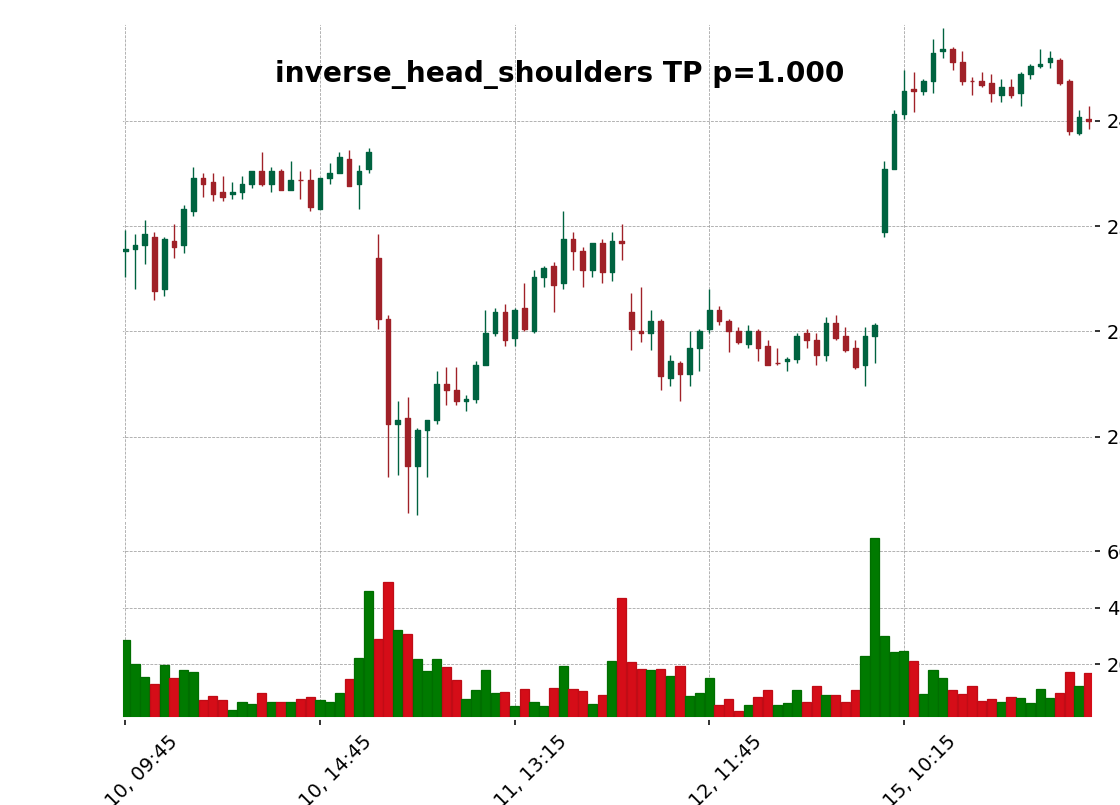

**FP**: _No examples were generated for this bucket._

### Inverse Head Shoulders FN examples

`inverse_head_shoulders_fn_17.png`

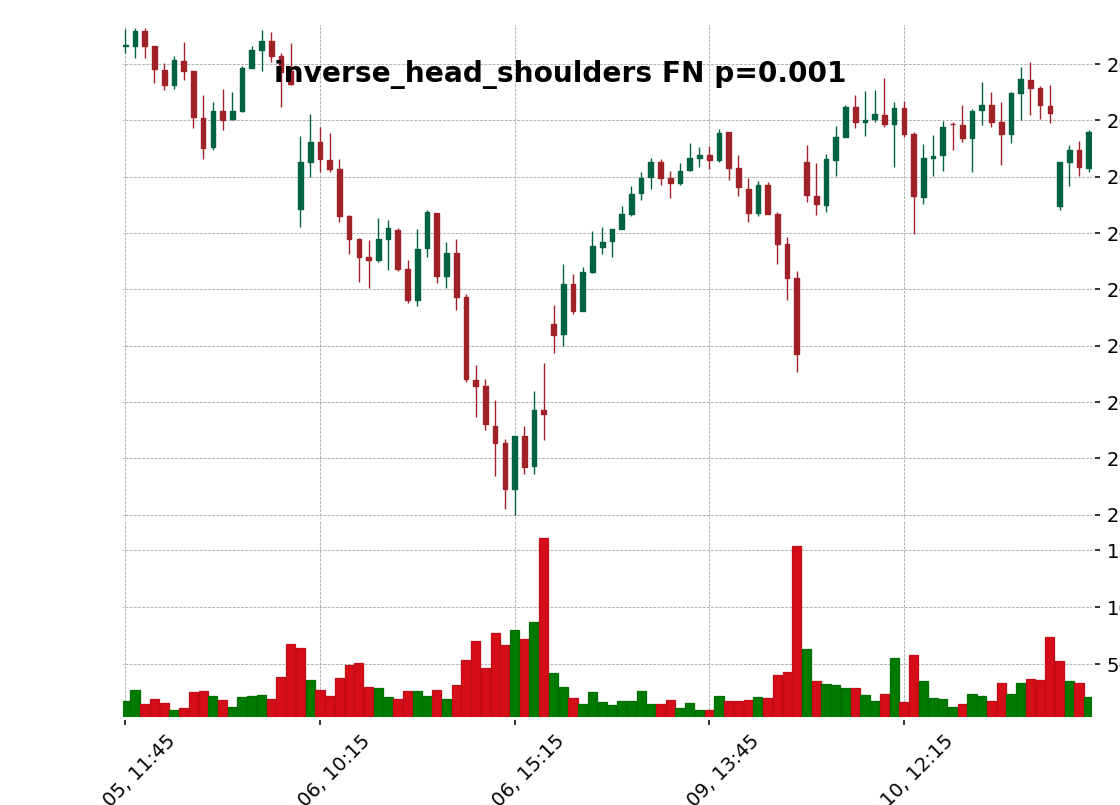

## Double Top gallery

### Double Top TP examples

`double_top_tp_9.png`

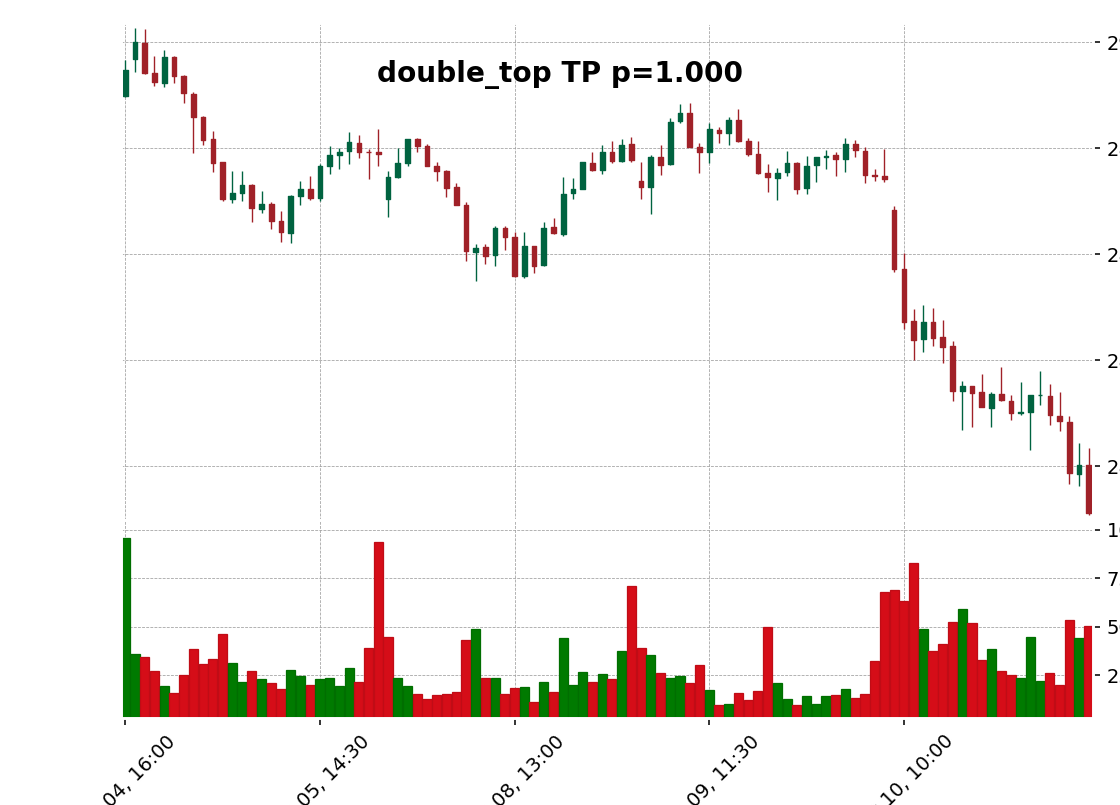

`double_top_tp_11.png`

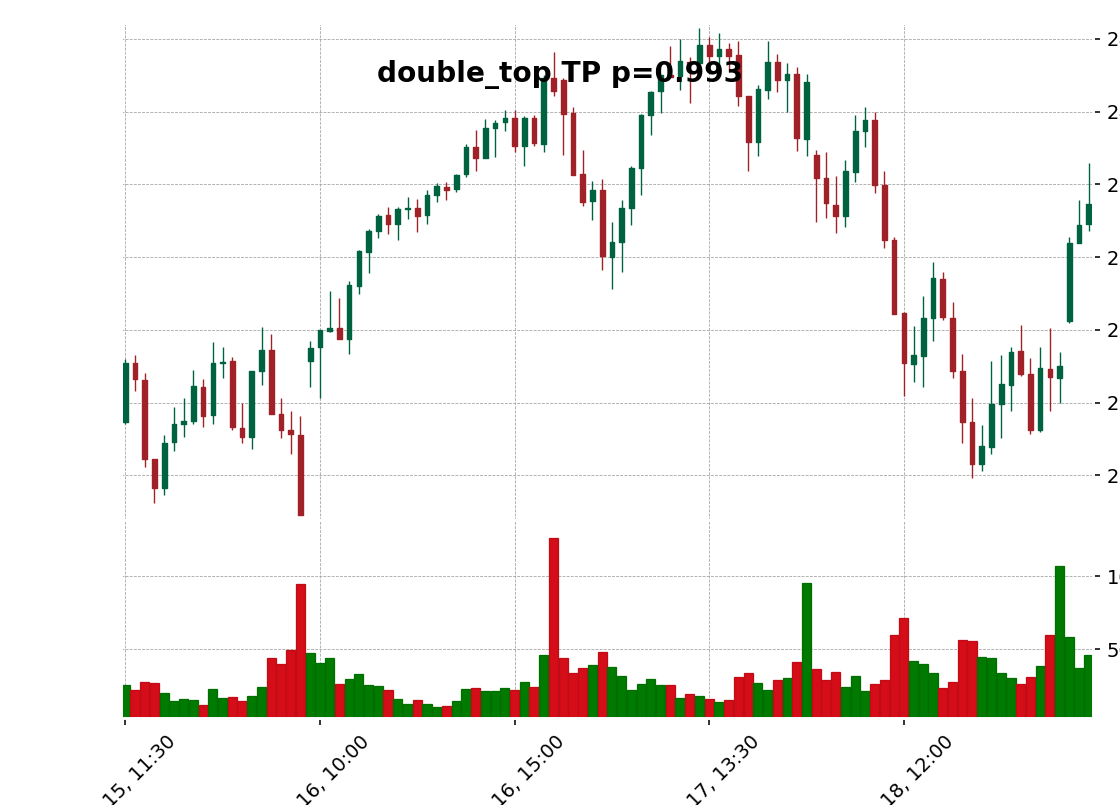

### Double Top FP examples

`double_top_fp_220.png`

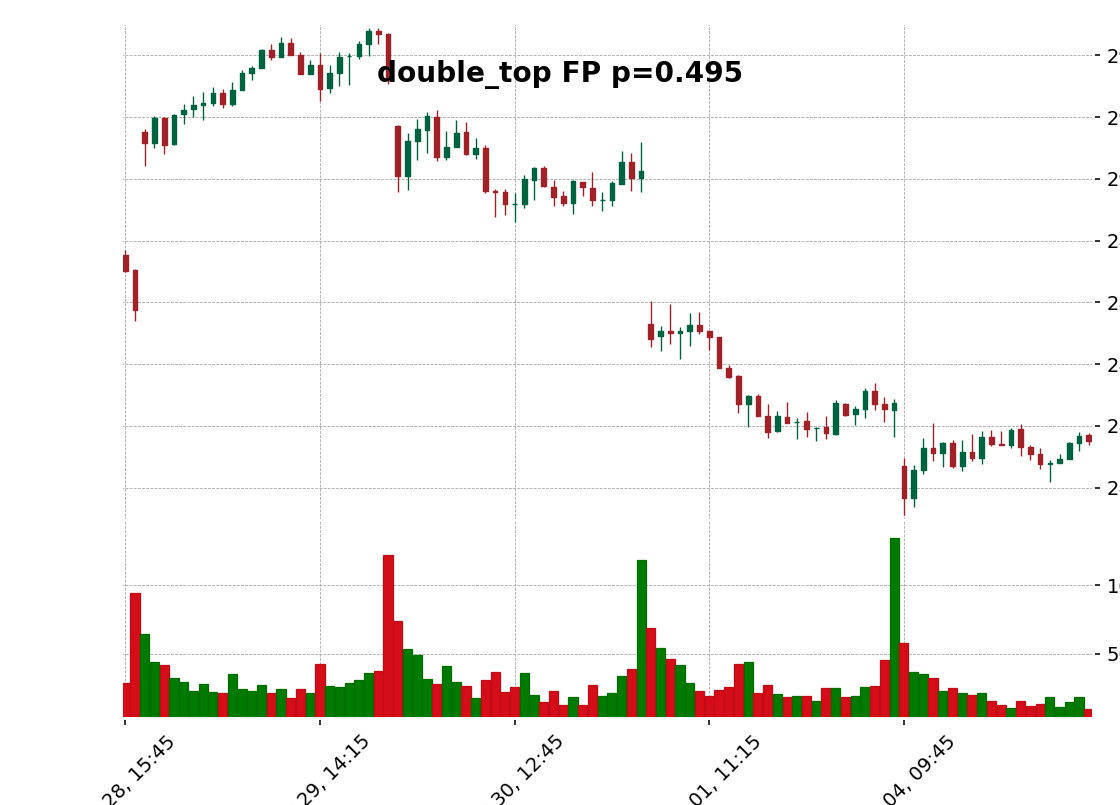

### Double Top FN examples

`double_top_fn_272.png`

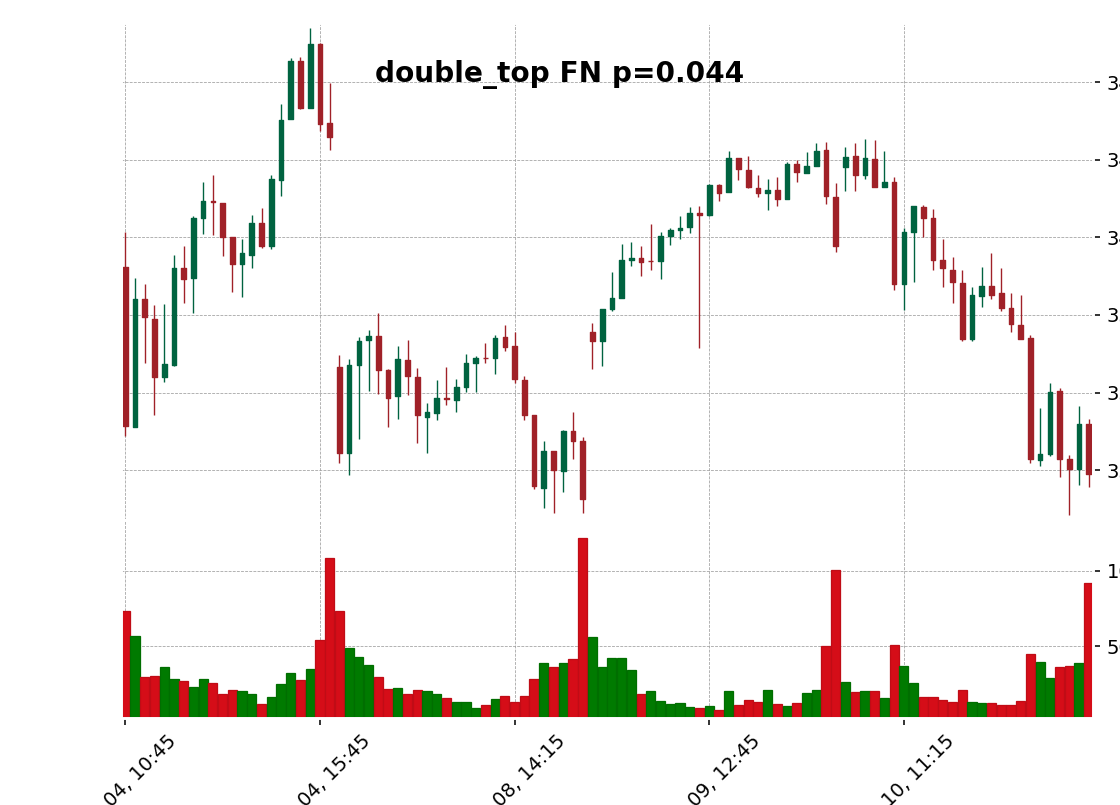

## Double Bottom gallery

### Double Bottom TP examples

`double_bottom_tp_25.png`

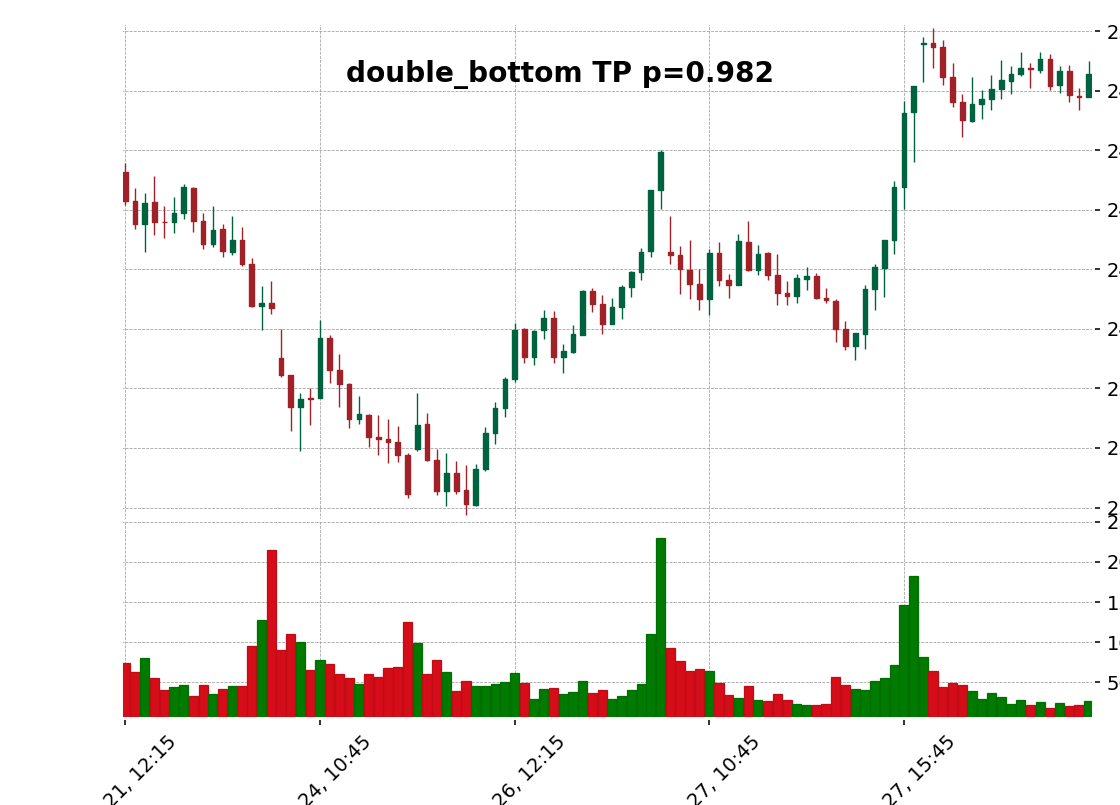

**FP**: _No examples were generated for this bucket._

**FN**: _No examples were generated for this bucket._

In [10]:
gallery_summary_path = roots["gallery_root"] / "gallery_summary.json"
if REUSE_EXISTING_RUN and gallery_summary_path.exists():
    print(f"Reusing existing gallery artifacts for run: {RUN_NAME}")
else:
    gallery_result = render_gallery(cfg)
    print(gallery_result["gallery_root"])

require_paths([gallery_summary_path], "Gallery stage")
gallery_summary = load_json(gallery_summary_path)
display(Markdown("### Gallery counts by pattern"))
display(pd.DataFrame(gallery_summary).T.reset_index().rename(columns={"index": "pattern"}))

for pattern in champions_df["pattern"].tolist():
    display(Markdown(f"## {pattern.replace('_', ' ').title()} gallery"))
    image_limit = 2 if pattern == flagship_pattern else 1
    for bucket in ["tp", "fp", "fn"]:
        index_path = gallery_index_path(roots, pattern, bucket)
        if not index_path.exists():
            display(Markdown(f"**{bucket.upper()}**: _No examples were generated for this bucket._"))
            continue
        bucket_df = read_csv_allow_empty(index_path)
        if bucket_df.empty:
            display(Markdown(f"**{bucket.upper()}**: _No examples were generated for this bucket._"))
            continue
        image_paths = bucket_df["file"].head(image_limit).tolist()
        show_image_grid(
            image_paths,
            title=f"{pattern.replace('_', ' ').title()} {bucket.upper()} examples",
            width=420,
        )

## SHAP Explainability

SHAP summaries are generated for the current run to identify influential feature groups, time steps, and local examples for the selected models.

outputs/explainability/fresh_sanity_notebook_20260424_000003


### Explainability run summary

,pattern,model_name,status,background_split,explain_split,background_samples,explained_samples,top_features,artifacts
0,inverse_head_shoulders,tcn,ok,train,test,64,32,"[t_minus_000_close, t_minus_000_high, t_minus_...",{'flat_feature_importance_csv': 'outputs/expla...
1,double_top,tcn,ok,train,test,64,32,"[t_minus_000_close, t_minus_000_low, t_minus_0...",{'flat_feature_importance_csv': 'outputs/expla...
2,double_bottom,tcn,ok,train,test,64,32,"[t_minus_000_close, t_minus_000_high, t_minus_...",{'flat_feature_importance_csv': 'outputs/expla...


## Flagship explainability deep dive: Double Top

,feature_group,mean_abs_shap
0,close,41.623882
1,low,35.951364
2,high,19.749105
3,open,13.562838
4,volume,0.212729


,feature,time_offset,bars_ago,feature_group,mean_abs_shap
0,t_minus_000_close,79,0,close,14.272119
1,t_minus_000_low,79,0,low,11.115427
2,t_minus_000_high,79,0,high,6.622624
3,t_minus_008_close,71,8,close,4.594098
4,t_minus_008_low,71,8,low,4.453199
5,t_minus_000_open,79,0,open,2.951883
6,t_minus_002_low,77,2,low,2.398688
7,t_minus_002_close,77,2,close,2.288162
8,t_minus_024_low,55,24,low,2.236589
9,t_minus_024_close,55,24,close,2.200187


### Flagship SHAP global views

`feature_group_importance.png`

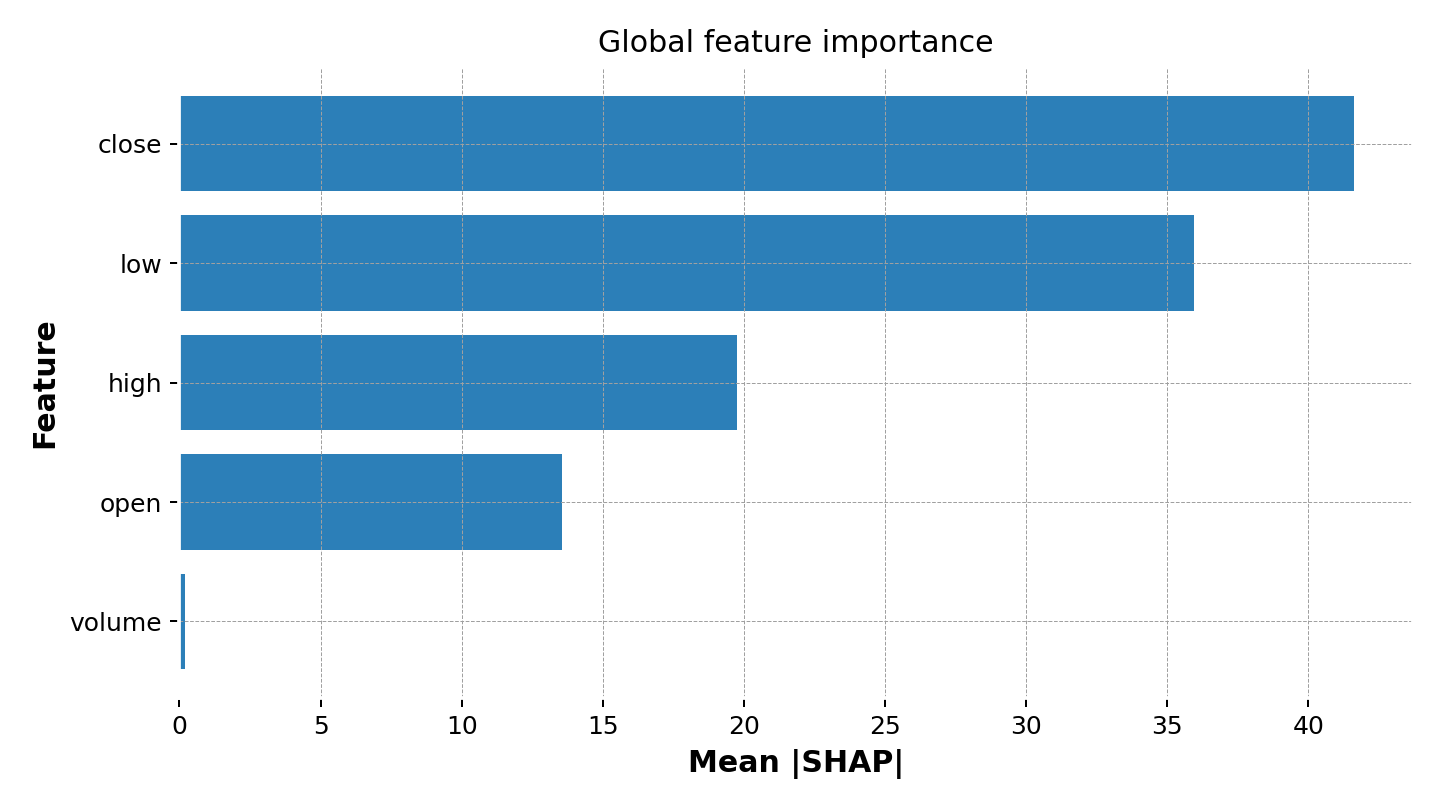

`temporal_heatmap.png`

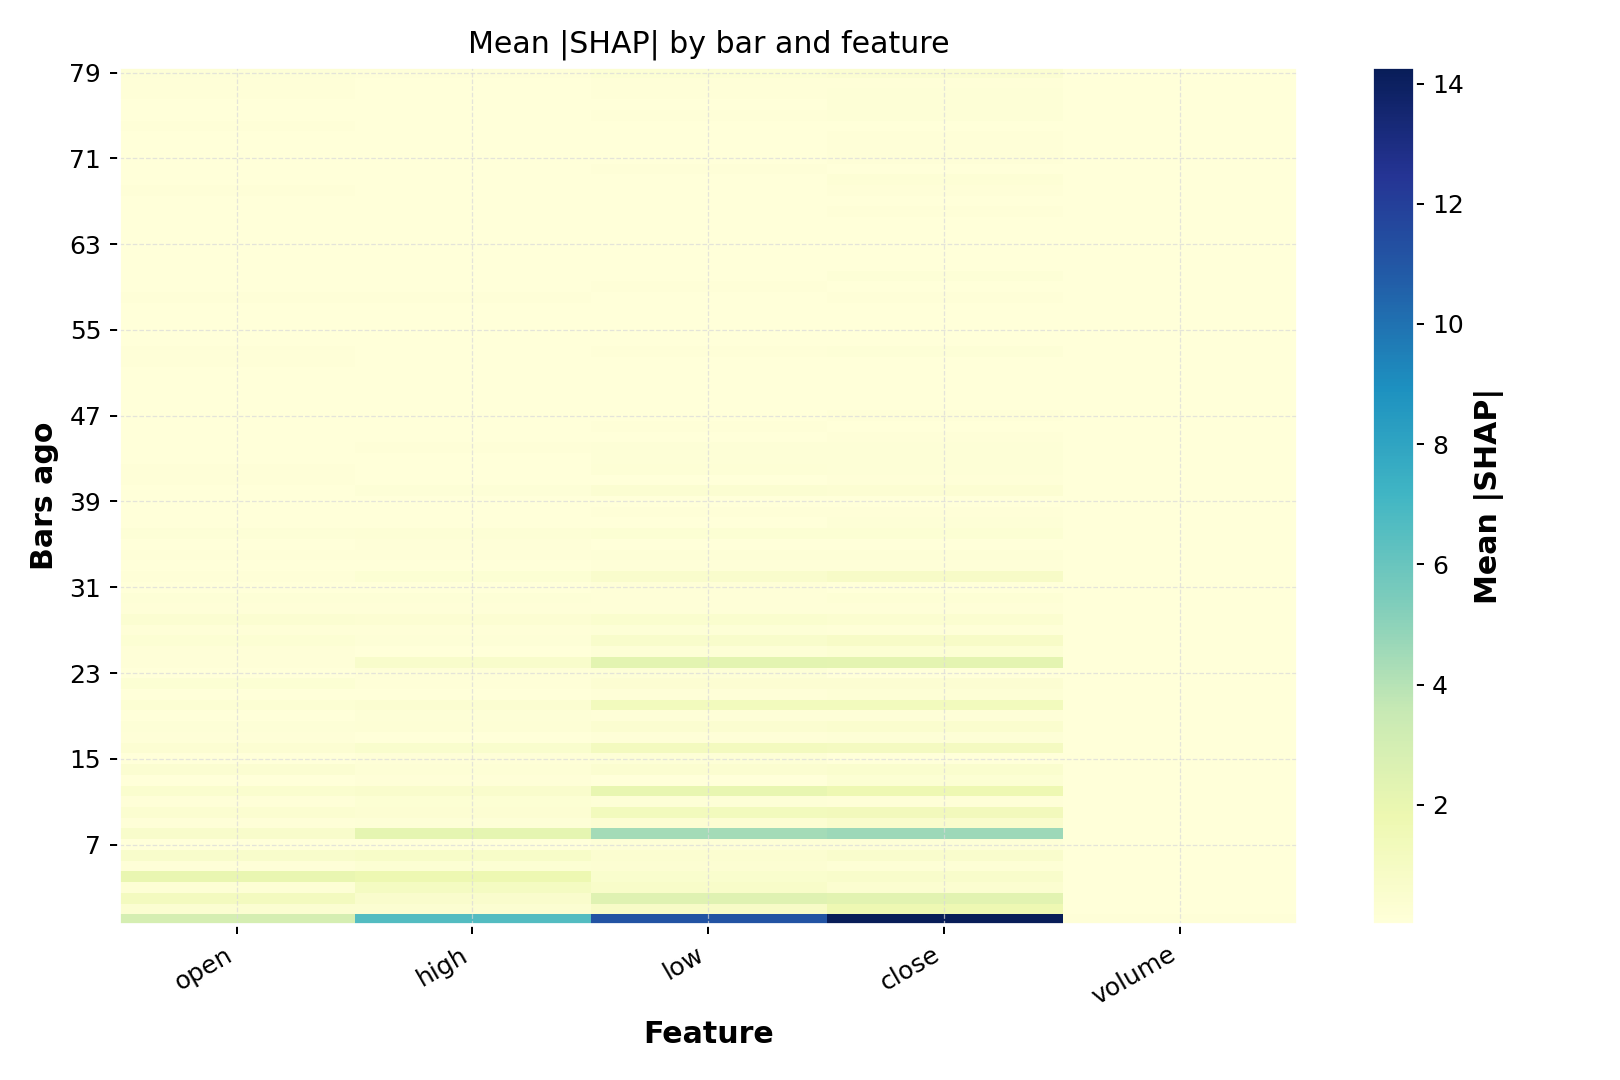

`top_window_features.png`

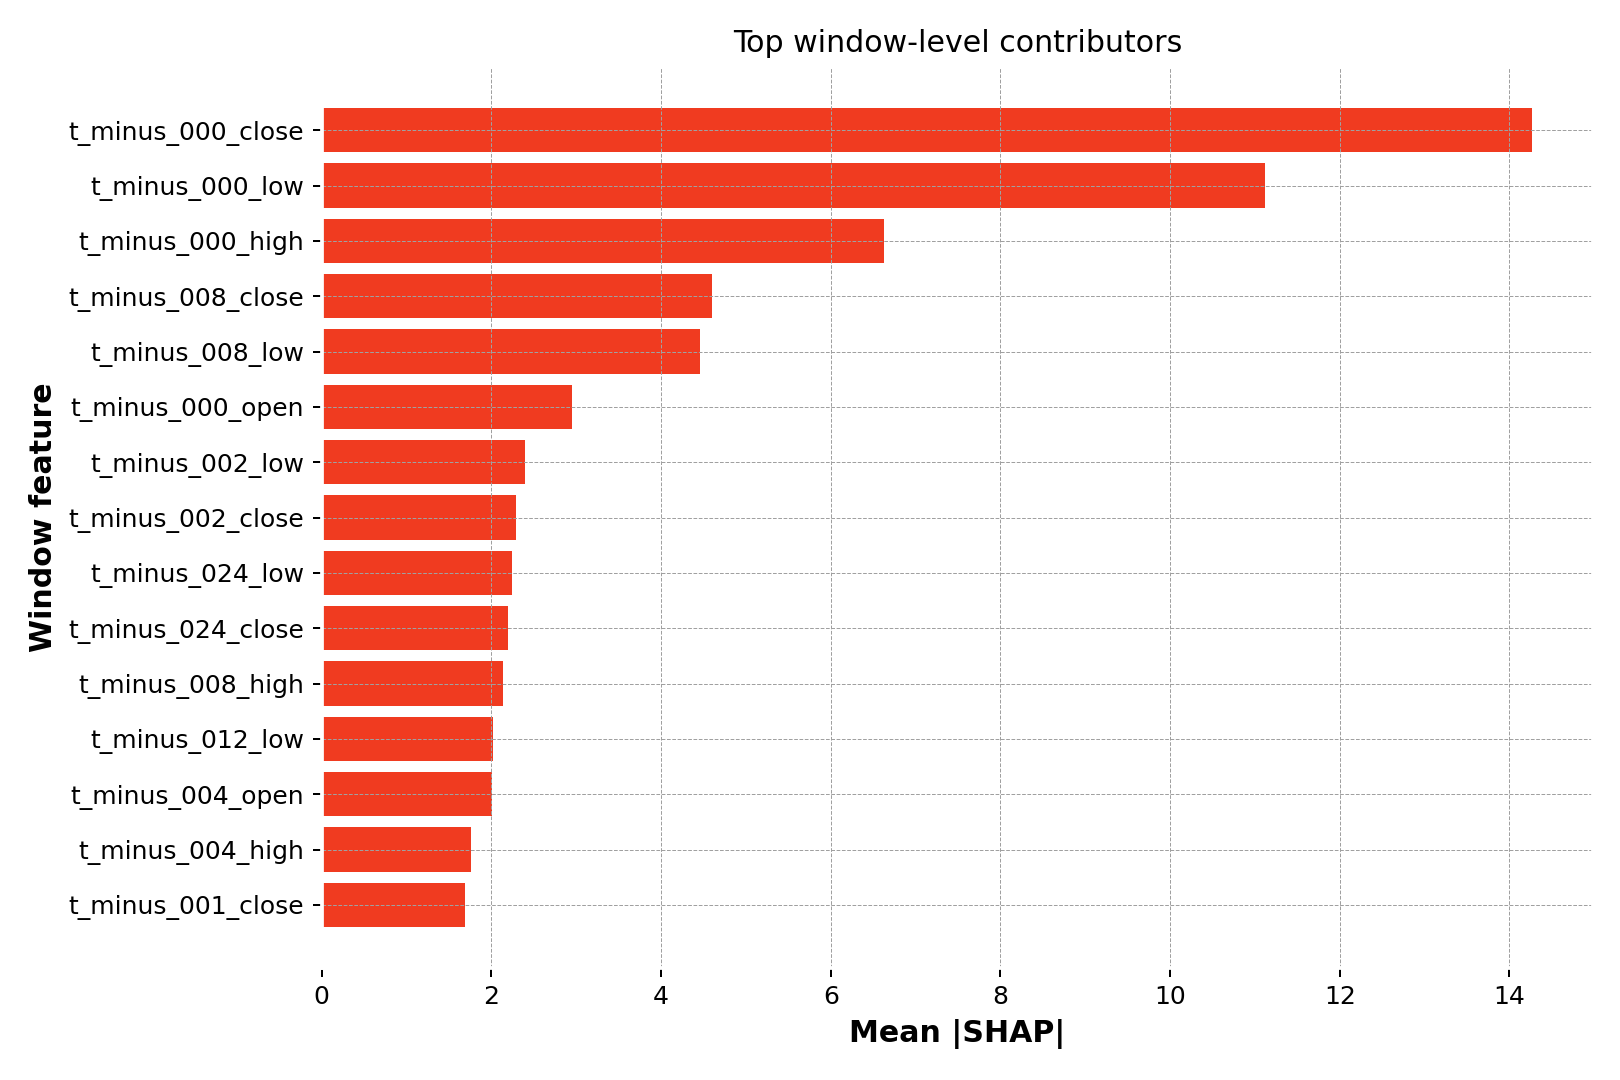

### Flagship local waterfall explanations

`sample_23_waterfall.png`

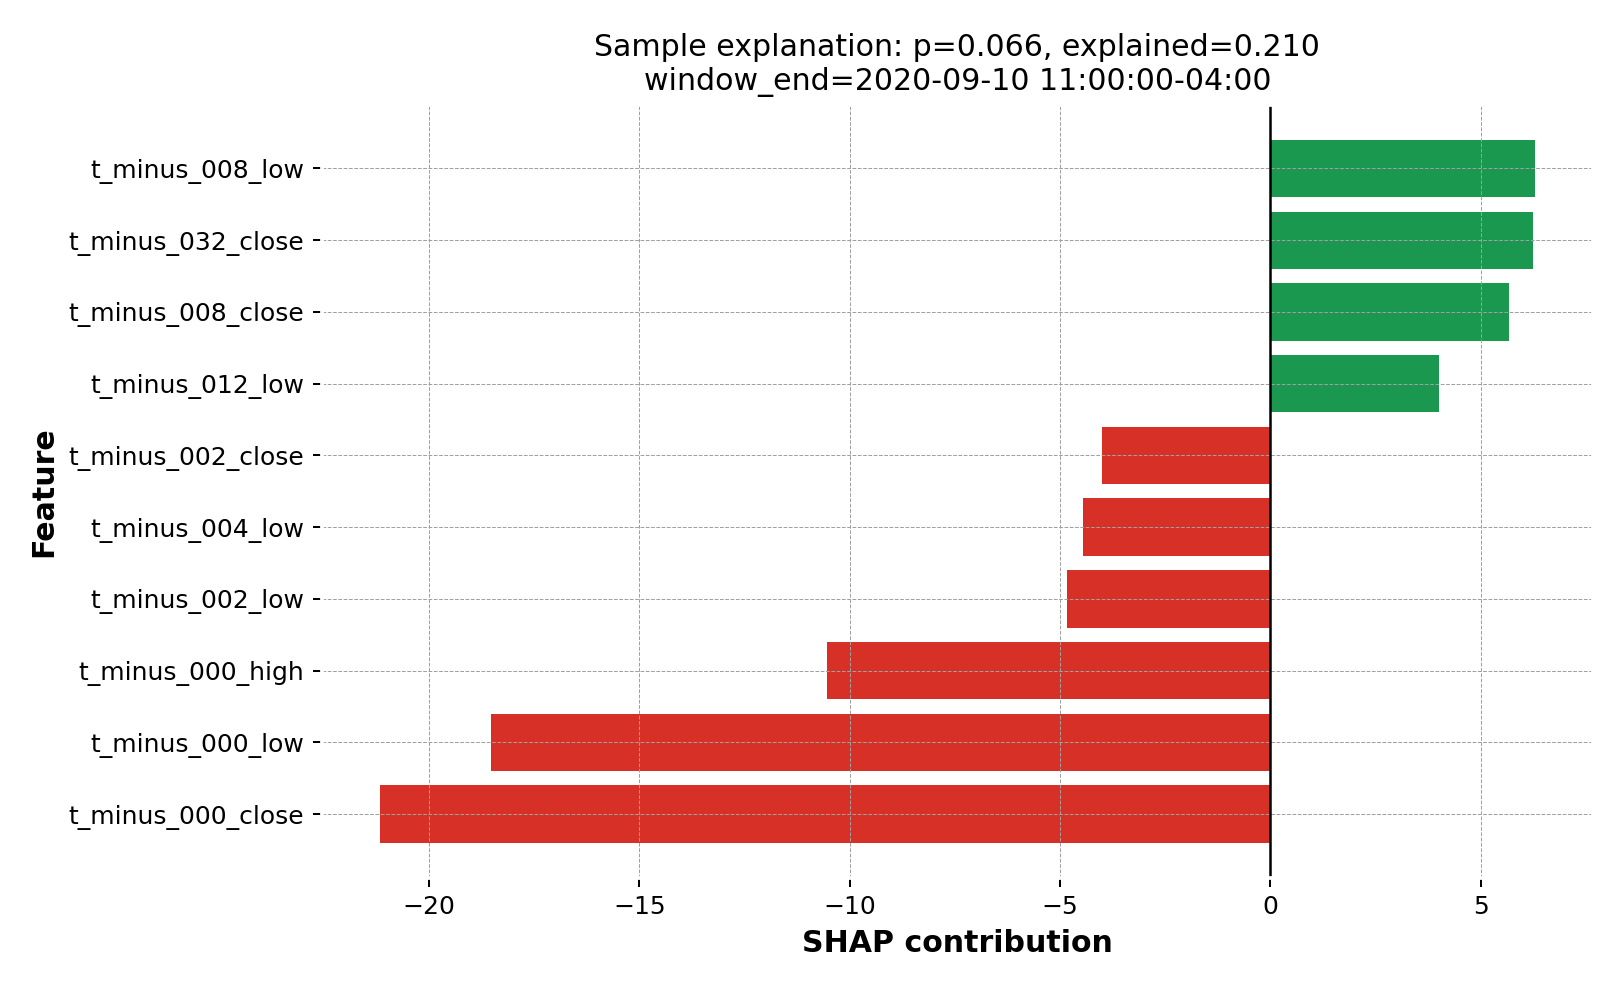

`sample_25_waterfall.png`

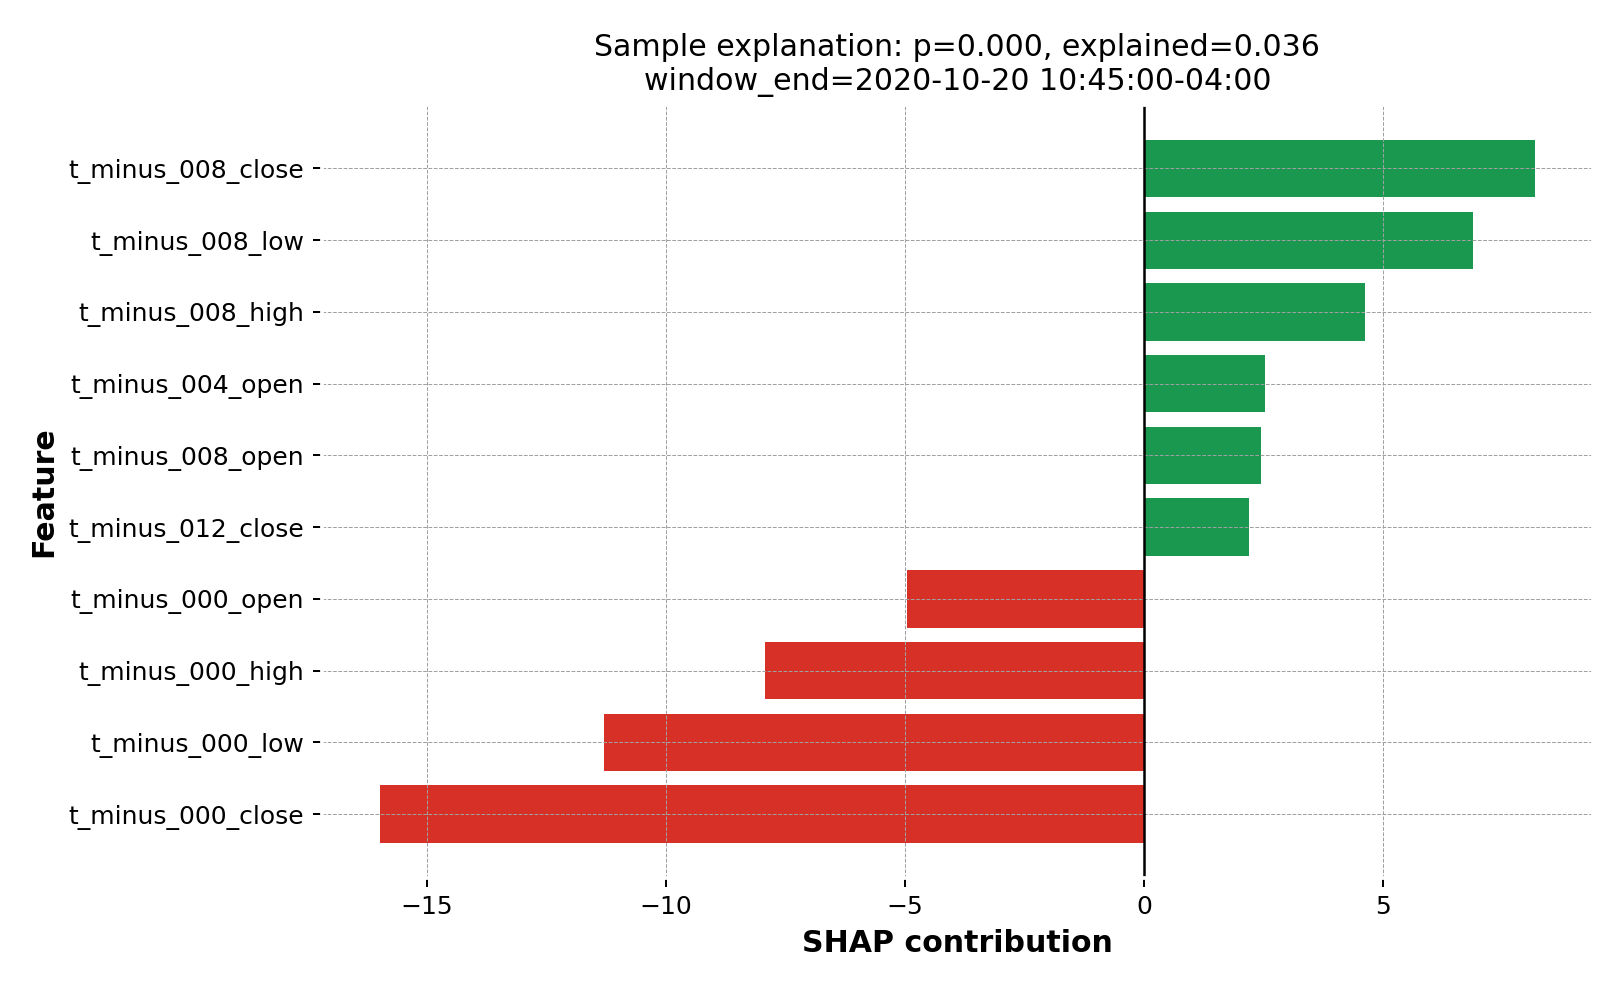

`sample_30_waterfall.png`

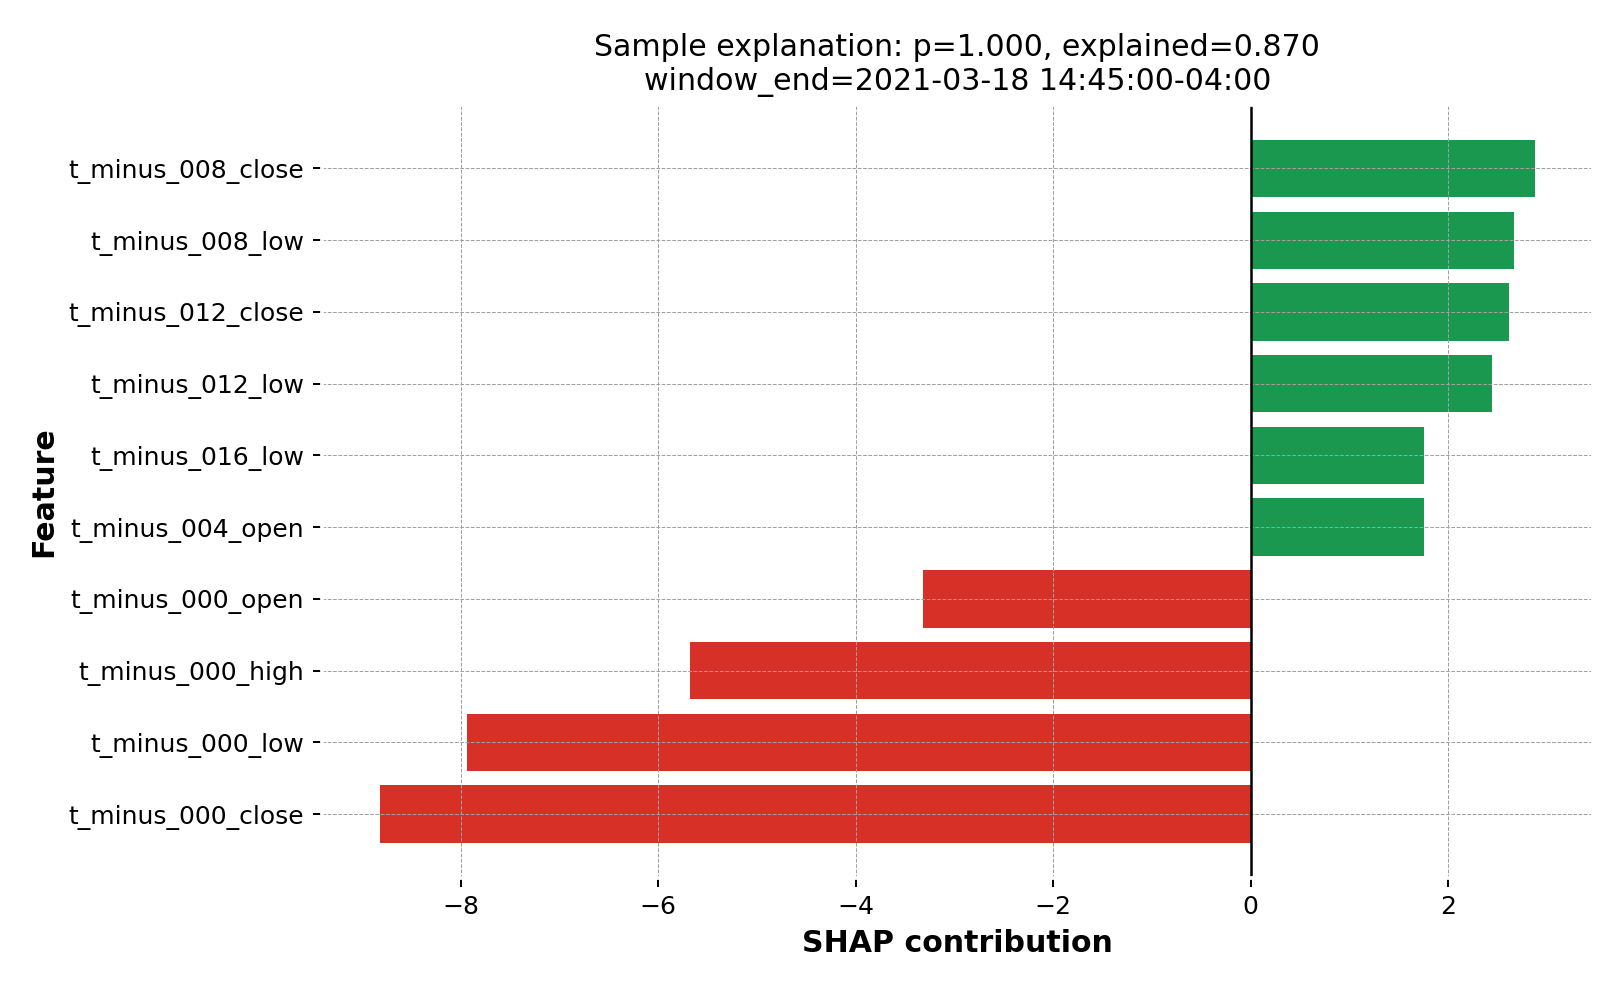

In [11]:
explainability_summary_path = roots["explainability_root"] / "explainability_summary.json"
if REUSE_EXISTING_RUN and explainability_summary_path.exists():
    print(f"Reusing existing explainability artifacts for run: {RUN_NAME}")
else:
    explainability_result = run_explainability_pipeline(
        cfg,
        run_name=RUN_NAME,
        explain_split=EXPLAIN_SPLIT,
        background_split=BACKGROUND_SPLIT,
        top_features=TOP_FEATURES,
        max_waterfalls=MAX_WATERFALLS,
    )
    print(explainability_result["output_root"])

require_paths([explainability_summary_path], "Explainability stage")
explainability_summary = load_json(explainability_summary_path)
display(Markdown("### Explainability run summary"))
display(pd.DataFrame(explainability_summary["results"]))

for pattern in champions_df["pattern"].tolist():
    pattern_root = roots["explainability_root"] / pattern
    require_paths(
        [
            pattern_root / "feature_group_importance.csv",
            pattern_root / "top_window_features.csv",
            pattern_root / "feature_group_importance.png",
            pattern_root / "temporal_heatmap.png",
            pattern_root / "top_window_features.png",
        ],
        f"Explainability artifacts for {pattern}",
    )

flagship_explain_root = roots["explainability_root"] / flagship_pattern
display(Markdown(f"## Flagship explainability deep dive: {flagship_pattern.replace('_', ' ').title()}"))
display(pd.read_csv(flagship_explain_root / "feature_group_importance.csv").head(10))
display(pd.read_csv(flagship_explain_root / "top_window_features.csv").head(10))
show_image_grid(
    [
        flagship_explain_root / "feature_group_importance.png",
        flagship_explain_root / "temporal_heatmap.png",
        flagship_explain_root / "top_window_features.png",
    ],
    title="Flagship SHAP global views",
    width=520,
)
waterfall_paths = sorted(flagship_explain_root.glob("sample_*_waterfall.png"))[:MAX_WATERFALLS]
show_image_grid(waterfall_paths, title="Flagship local waterfall explanations", width=520)

## Results and Recommendations

This section separates held-out classification results, qualitative evidence, interpretability, limitations, and downstream backtest evidence. Recommendations are based primarily on test-set classification behaviour, with backtest results used as supporting context.

In [12]:
backtest_df = pd.DataFrame()
if RUN_BACKTEST:
    backtest_summary_path = roots["backtest_root"] / "backtest_summary.csv"
    if REUSE_EXISTING_RUN and backtest_summary_path.exists():
        print(f"Reusing existing backtest artifacts for run: {RUN_NAME}")
    else:
        backtest_result = run_backtest(cfg)
        print(backtest_result["backtest_root"])
    require_paths([backtest_summary_path], "Backtest stage")
    backtest_df = pd.read_csv(backtest_summary_path)
    display(Markdown("### Backtest summary"))
    display(backtest_df.sort_values("total_pnl", ascending=False))
else:
    display(Markdown("_Backtest skipped because `RUN_BACKTEST=False`._"))

reference_macro_path = REPO_ROOT / "outputs/metrics/production_repro_handoff_clean_20260419/macro_summary.json"
if reference_macro_path.exists():
    reference_macro = load_json(reference_macro_path)
    directional_validation = pd.DataFrame(
        [
            {
                "metric": metric,
                "current_run": macro_summary.get(metric),
                "historical_reference": reference_macro.get(metric),
            }
            for metric in ["macro_f1", "macro_f2", "macro_precision", "macro_recall"]
        ]
    )
    display(Markdown("### Directional validation against a historical reference run"))
    display(directional_validation)

strongest_pattern = champion_metrics.sort_values("f1", ascending=False).iloc[0]
weakest_recall_pattern = champion_metrics.sort_values("recall", ascending=True).iloc[0]
recommendations = [
    f"Strongest held-out classifier: **{strongest_pattern['pattern']}** with F1={strongest_pattern['f1']:.3f} and precision={strongest_pattern['precision']:.3f}.",
    f"Most recall-constrained pattern: **{weakest_recall_pattern['pattern']}** with recall={weakest_recall_pattern['recall']:.3f}; this is the first candidate for more data or looser rule design.",
    "Use the TP/FP/FN gallery as a governance tool, not just a presentation aid, because it exposes whether model decisions remain visually plausible under false-positive and false-negative cases.",
    "Preserve SHAP alongside the gallery outputs in any future client-facing deployment so that pattern alerts remain inspectable at both the global and local level.",
    "Treat thin-support patterns cautiously and expand the prototype with more historical coverage, additional instruments, or stress-test periods before any operational use.",
]

if not backtest_df.empty:
    best_backtest = backtest_df.sort_values("total_pnl", ascending=False).iloc[0]
    recommendations.insert(
        1,
        f"Best trading-style outcome in this run: **{best_backtest['pattern']}** with total PnL={best_backtest['total_pnl']:.2f} and win rate={best_backtest['win_rate']:.3f}.",
    )

limitations = [
    "The dataset covers a single instrument, SPY, so cross-asset generalisation is untested.",
    "Labels depend on rule-based pattern definitions and their configured breakout criteria.",
    "Patterns with thin positive support have less stable precision and recall estimates.",
    "The backtest is an illustrative downstream analysis, not evidence of deployable trading performance.",
]

display(Markdown("### Limitations"))
display(Markdown("\n".join(f"- {item}" for item in limitations)))

display(Markdown("### Findings and recommendations"))
display(Markdown("\n".join(f"- {item}" for item in recommendations)))

acceptance_checks = pd.DataFrame(
    [
        {"check": "Processed 15-minute dataset exists", "passed": roots["processed_15m"].exists()},
        {"check": "Metrics outputs exist", "passed": roots["metrics_root"].exists()},
        {"check": "Gallery outputs exist", "passed": roots["gallery_root"].exists()},
        {"check": "Explainability outputs exist", "passed": roots["explainability_root"].exists()},
        {"check": "Backtest outputs exist or were skipped intentionally", "passed": (not RUN_BACKTEST) or roots["backtest_root"].exists()},
        {"check": "Champion table is populated", "passed": not champions_df.empty},
    ]
)
display(Markdown("### Acceptance checks"))
display(acceptance_checks)

if not acceptance_checks["passed"].all():
    raise AssertionError("One or more acceptance checks failed. Inspect the table above before submission.")

Backtest finished. Outputs at: outputs/backtest/fresh_sanity_notebook_20260424_000003
outputs/backtest/fresh_sanity_notebook_20260424_000003


### Backtest summary

,trades,signals_total,accepted_signals,rejected_signals,return_on_capital,total_pnl,win_rate,sharpe,profit_factor,max_drawdown,...,average_portfolio_heat,max_portfolio_heat,rejected_same_pattern_overlap,rejected_max_open_positions,rejected_portfolio_heat,rejected_zero_size,rejected_invalid_stop,rejected_tiny_stop,rejected_no_future_bar,pattern
0,17,17,17,0,0.016931,16930.992639,0.705882,0.902480,2.641523,-2752.130023,...,0.001856,0.0025,0,0,0,0,0,0,0,inverse_head_shoulders
2,18,19,18,1,0.004681,4680.701307,0.500000,0.253490,1.212334,-10625.225728,...,0.002293,0.0025,0,0,0,0,1,0,0,double_bottom
1,22,22,22,0,-0.010927,-10926.999276,0.363636,-0.500166,0.708039,-22074.560343,...,0.002412,0.0025,0,0,0,0,0,0,0,double_top


### Directional validation against a historical reference run

,metric,current_run,historical_reference
0,macro_f1,0.966330,0.891414
1,macro_f2,0.956175,0.856020
2,macro_precision,0.984848,0.988636
3,macro_recall,0.949761,0.837321


...

- The dataset covers a single instrument, SPY, so cross-asset generalisation is untested.
- Labels depend on rule-based pattern definitions and their configured breakout criteria.
- Patterns with thin positive support have less stable precision and recall estimates.
- The backtest is an illustrative downstream analysis, not evidence of deployable trading performance.

### Findings and recommendations

- Strongest held-out classifier: **double_bottom** with F1=1.000 and precision=1.000.
- Best trading-style outcome in this run: **inverse_head_shoulders** with total PnL=16930.99 and win rate=0.706.
- Most recall-constrained pattern: **inverse_head_shoulders** with recall=0.895; this is the first candidate for more data or looser rule design.
- Use the TP/FP/FN gallery as a governance tool, not just a presentation aid, because it exposes whether model decisions remain visually plausible under false-positive and false-negative cases.
- Preserve SHAP alongside the gallery outputs in any future client-facing deployment so that pattern alerts remain inspectable at both the global and local level.
- Treat thin-support patterns cautiously and expand the prototype with more historical coverage, additional instruments, or stress-test periods before any operational use.

### Acceptance checks

,check,passed
0,Processed 15-minute dataset exists,True
1,Metrics outputs exist,True
2,Gallery outputs exist,True
3,Explainability outputs exist,True
4,Backtest outputs exist or were skipped intenti...,True
5,Champion table is populated,True
